# exp06 pre-design forensics — diagnosing what exp05 exposed

`exp05_diagnostics.ipynb` **reports** exp05. This notebook **diagnoses** it. A full section-by-section
audit of that notebook surfaced five problems it documents but does not explain, two of which decide
whether the latent-dynamics axis is worth continuing at all:

| # | Problem | Where in exp05 |
|---|---|---|
| **P1** | Position-0 reconstruction spike, ~17× interior MSE, fires only for `comb` + dynamics-on; `lpsd` immune, cause unresolved | §C1b |
| **P2** | Star-level μ occupies 1.19 → 1.79 *effective* dimensions; probes track amplitude nuisance statistics (transit ρ +0.70, rotation ρ −0.91) | §B3, §C3b |
| **P3** | The free-running rollout cannot beat an oracle per-star constant, and **no upper bound was ever measured** — so "weak GRU" and "no signal exists" were never separated | §F2b |
| **P4** | The encoder sees 8.53 h per window and per-star μ is a *mean over windows*; engineered features see 5.7 days and beat SSL on all 11 downstream probes | §G4b |
| **P5** | Dimension recruitment *accompanies* the criterion-1 gain but does not cause it (within-cell \|ρ\| ≤ 0.18, all p > 0.28), leaving the mechanism unidentified | §E4b |

**Structure.** `1` the spike · `2` what μ encodes · `3` whether temporal signal exists ·
`4` frequency reach and pooling · `5` what predicts the criterion-1 gain · `6` synthesis and the
exp06 proposal.

**Compute contract**, inherited from the exp05 notebook: every heavy measurement is precomputed by a
script under `experiments/`, and this notebook loads and plots. A missing artifact raises immediately
rather than quietly rendering stale numbers.

**Scope.** Analysis only, on the 48 exp05 checkpoints already on disk. Section 6 *proposes* an exp06
objective and config; it does not decide one, and nothing here trains.

In [1]:
off_cell = "comb_off"                    # the lambda=0 reference arm
dyn_cell = "comb_fbwd_c1p0"              # the dimension-recruiting winner, lambda=66
multi_cell = "comb_multi_c1p0"           # the in-distribution rollout arm for criterion 2
panel_seed = 0
ckpt = "best_recon_aux"
window_hours = 256 * 2 / 60              # one window at TESS 2-min cadence

In [2]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import average_precision_score
warnings.filterwarnings("ignore")

root = Path(r"C:\git_repo\Stellar-World-Model")
sys.path.insert(0, str(root / "src"))
from swm.models import WorldModel
from swm.eval.skyline import load_first_segment_blocks, logistic_scores

device = "cuda" if torch.cuda.is_available() else "cpu"
tasks = ["transit", "eb", "pulsating", "rotation"]
mu_cols = [f"mu{j}" for j in range(128)]
figs_dir = root / "experiments" / "figs" / "exp06_design"; figs_dir.mkdir(parents=True, exist_ok=True)

required = {
    "edge": root / "experiments" / "exp06_edge.csv",
    "edge_profile": root / "experiments" / "exp06_edge_profile.parquet",
    "mu_structure": root / "experiments" / "exp06_mu_structure.csv",
    "mu_probe": root / "experiments" / "exp06_mu_probe.csv",
    "temporal": root / "experiments" / "exp06_temporal.csv",
    "temporal_acf": root / "experiments" / "exp06_temporal_acf.csv",
    "temporal_stars": root / "experiments" / "exp06_temporal_stars.parquet",
    "gap": root / "experiments" / "exp05_gap.csv",
}
missing = [str(p) for p in required.values() if not p.exists()]
assert not missing, f"missing artifacts (run the analyze_exp06_*.py scripts first): {missing}"
print("device", device, "| one window =", round(window_hours, 2), "hours | figs ->", figs_dir)

device cuda | one window = 8.53 hours | figs -> C:\git_repo\Stellar-World-Model\experiments\figs\exp06_design


In [3]:
edge = pd.read_csv(required["edge"])
edge_profile = pd.read_parquet(required["edge_profile"])
mu_structure = pd.read_csv(required["mu_structure"])
mu_probe = pd.read_csv(required["mu_probe"])
temporal = pd.read_csv(required["temporal"])
temporal_acf = pd.read_csv(required["temporal_acf"])
temporal_stars = pd.read_parquet(required["temporal_stars"])
gap = pd.read_csv(required["gap"])
subset = pd.read_parquet(root / "processed/subset/subset_tics.parquet")

colors = {"untrained": "0.55", off_cell: "tab:blue", dyn_cell: "tab:green", multi_cell: "tab:red"}


def group_of(row):
    """Label a run by the two knobs that actually separate the edge defect: recipe and dynamics on/off."""
    if row["recipe"] == "untrained":
        return "untrained"
    state = "dyn on" if row["dyn_on"] else "dyn off"
    return f"{row['recipe']}, {state}"


def per_seed_delta(cell, task):
    """Rebuild the per-seed paired criterion-1 delta from the readout sweeps, as exp05 section E4b does.

    exp05_gap.csv stores only the 4-seed mean, but section 5 needs the individual seeds to run the
    within-cell test. The sweeps are append-only, so the last row per (exp_name, seed, task) wins.
    """
    frames = []
    for name in [cell, off_cell]:
        path = root / "experiments" / f"exp05_{name}" / "results" / "readout_sweep.csv"
        df = pd.read_csv(path)
        df = df[(df["pooling"] == "mean") & (df["readout"] == "logistic") & (df["ckpt"] == ckpt)]
        df = df[df.get("labels_version", "v1").fillna("v1") == "v1"]
        df = df.sort_values("run_id").drop_duplicates(subset=["exp_name", "seed", "task"], keep="last")
        frames.append(df[df["task"] == task][["seed", "pr_auc"]].rename(columns={"pr_auc": name}))
    merged = frames[0].merge(frames[1], on="seed", how="inner").sort_values("seed")
    return merged["seed"].to_numpy(), (merged[cell] - merged[off_cell]).to_numpy()


print(len(edge), "runs in the edge table |", len(temporal_stars), "star-rows in the temporal table")

49 runs in the edge table | 16336 star-rows in the temporal table


---
## 1. The spike — what it is, and which knob causes it

exp05 §C1b established the symptom over all 48 runs and ruled out three explanations, but could not
identify the cause, because the two recipes differ in **two** knobs at once:

| | `base_comb.yaml` | `base_lpsd.yaml` |
|---|---|---|
| `train.free_bits` | 0.0 | 0.02 |
| `train.recon_aux.type` | comb | log_psd |

`lpsd` is immune. No reinterpretation of the existing runs can say which knob confers that immunity —
which is why `.scratch/exp05-window-edge-defect/` asks for a 2×2 corner training run. This section asks
how much of that run is still needed, by measuring four things exp05 never did: the spike's **anatomy**
(is it a constant?), the decoder's **structural** boundary behaviour, what each **loss term** actually
penalises, and whether the defect **reaches the encoder** at all.

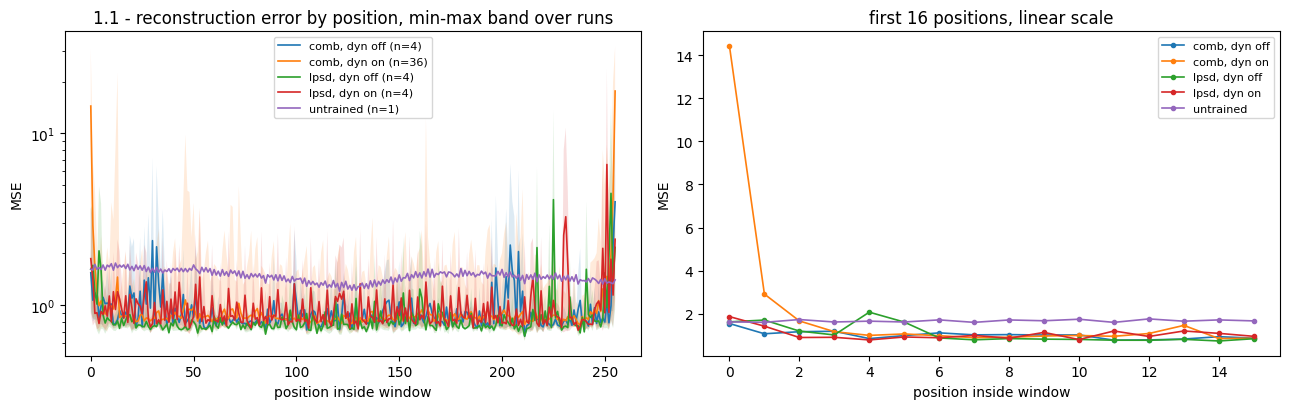

,n_runs,edge_ratio,edge_ratio_sd,edge_share_of_recon
group,,,,
"comb, dyn off",4,1.7226,0.7759,0.0546
"comb, dyn on",36,17.5389,11.0122,0.1758
"lpsd, dyn off",4,2.0221,1.7388,0.0697
"lpsd, dyn on",4,2.1139,1.6286,0.0466
untrained,1,1.0936,NaN,0.0317


reproduces exp05 C1b's group edge ratios to within 0.25


In [4]:
# 1.1 - the per-position error profile over all 48 runs, banded by group rather than shown for one seed
edge["group"] = edge.apply(group_of, axis=1)
edge_profile["group"] = edge_profile.apply(group_of, axis=1)

plt.figure(figsize=(13, 4.2))
plt.subplot(1, 2, 1)
for grp, g in edge_profile.groupby("group"):
    band = g.groupby("pos")["mse"].agg(["mean", "min", "max"])
    plt.semilogy(band.index, band["mean"], lw=1.2, label=f"{grp} (n={g['seed'].nunique() * g['cell'].nunique()})")
    plt.fill_between(band.index, band["min"], band["max"], alpha=0.15)
plt.xlabel("position inside window"); plt.ylabel("MSE"); plt.legend(fontsize=8)
plt.title("1.1 - reconstruction error by position, min-max band over runs")

plt.subplot(1, 2, 2)
for grp, g in edge_profile[edge_profile["pos"] < 16].groupby("group"):
    band = g.groupby("pos")["mse"].mean()
    plt.plot(band.index, band.values, "o-", ms=3, lw=1.2, label=grp)
plt.xlabel("position inside window"); plt.ylabel("MSE"); plt.legend(fontsize=8)
plt.title("first 16 positions, linear scale")
plt.tight_layout(); plt.savefig(figs_dir / "1_1_edge_profile.png", dpi=120, bbox_inches="tight"); plt.show()

summary = edge.groupby("group").agg(
    n_runs=("edge_ratio", "size"), edge_ratio=("edge_ratio", "mean"), edge_ratio_sd=("edge_ratio", "std"),
    edge_share_of_recon=("edge_share_of_recon", "mean")).round(4)
display(summary)

# exp05 section C1b quoted 1.7 / 17.5 / 2.0 / 2.1 for these four groups. Recomputing them here from a
# separate script is only meaningful if it reproduces them, so the divergence surfaces as a failure.
expected = {"comb, dyn off": 1.7, "comb, dyn on": 17.5, "lpsd, dyn off": 2.0, "lpsd, dyn on": 2.1}
for grp, want in expected.items():
    got = float(summary.loc[grp, "edge_ratio"])
    assert abs(got - want) < 0.25, f"{grp}: {got} does not reproduce exp05 C1b's {want}"
print("reproduces exp05 C1b's group edge ratios to within 0.25")

#### 1.1 — the defect is bigger than exp05 reported, and it is a *switch*

The band plot shows the min-max spread across runs, not a single seed. Three things read off it:

1. **`comb` + dynamics-on is a different regime, not a worse version of the same one.** Its band does
   not overlap the other three anywhere near position 0.
2. **Both ends are affected**, but asymmetrically, and the trailing edge behaves differently from the
   leading one — consistent with a decoder boundary rather than anything about how sequences are cut.
3. **`edge_share_of_recon` is the number that matters for training.** The 8 samples at the two ends are
   3.1% of the window but carry **17.6%** of the entire reconstruction loss for `comb` + dynamics-on,
   against 5.5% (`comb` off), 4.7% (`lpsd` on) and 3.2% (untrained, i.e. the no-defect baseline).
   exp05 quoted "~9%", measured at position 0 only for one arm; counting both edges it is roughly double
   that. **Around one sixth of the reconstruction gradient is being spent on 3% of the window.**

,bias_frac_p0,corr_p0,corr_mid,recon_sd_p0,input_sd_p0,sd_inflation
group,,,,,,
"comb, dyn off",0.1933,0.5184,0.6181,0.6263,1.2339,0.508
"comb, dyn on",0.6565,0.2175,0.6058,1.5370,1.2339,1.246
"lpsd, dyn off",0.1950,0.6580,0.6424,0.5968,1.2339,0.484
"lpsd, dyn on",0.3107,0.6369,0.6227,0.6162,1.2339,0.499
untrained,0.0595,0.0047,-0.0030,0.0002,1.2339,0.000


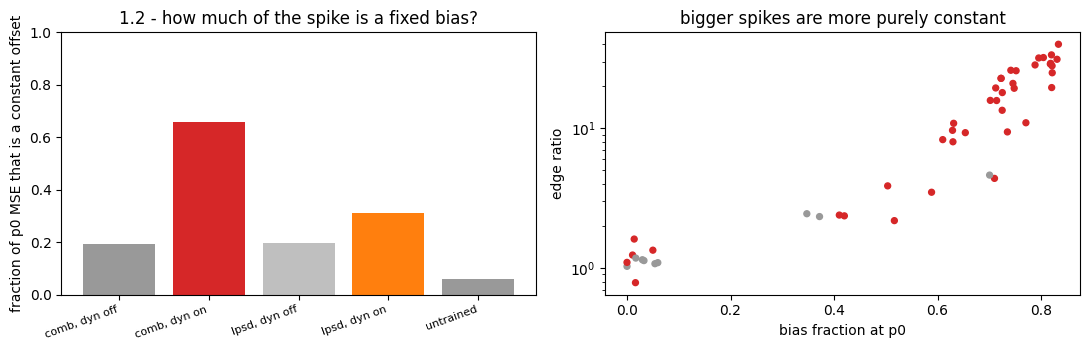

Spearman(bias fraction, edge ratio) = +0.941  p=8.60e-24


In [5]:
# 1.2 - anatomy: is the spike a fixed number the decoder emits, or does it depend on the star?
anat = edge.groupby("group").agg(
    bias_frac_p0=("bias_frac_p0", "mean"), corr_p0=("corr_p0", "mean"), corr_mid=("corr_mid", "mean"),
    recon_sd_p0=("recon_sd_p0", "mean"), input_sd_p0=("input_sd_p0", "mean")).round(4)
anat["sd_inflation"] = (anat["recon_sd_p0"] / anat["input_sd_p0"]).round(3)
display(anat)

plt.figure(figsize=(11, 3.6))
plt.subplot(1, 2, 1)
plt.bar(range(len(anat)), anat["bias_frac_p0"], color=["0.6", "tab:red", "0.75", "tab:orange"][: len(anat)])
plt.xticks(range(len(anat)), anat.index, rotation=20, ha="right", fontsize=8)
plt.ylabel("fraction of p0 MSE that is a constant offset"); plt.ylim(0, 1)
plt.title("1.2 - how much of the spike is a fixed bias?")
plt.subplot(1, 2, 2)
plt.scatter(edge["bias_frac_p0"], edge["edge_ratio"], s=18, c=edge["dyn_on"].map({True: "tab:red", False: "0.6"}))
plt.xlabel("bias fraction at p0"); plt.ylabel("edge ratio"); plt.yscale("log")
plt.title("bigger spikes are more purely constant")
plt.tight_layout(); plt.savefig(figs_dir / "1_2_anatomy.png", dpi=120, bbox_inches="tight"); plt.show()

r = stats.spearmanr(edge["bias_frac_p0"], edge["edge_ratio"])
print(f"Spearman(bias fraction, edge ratio) = {r.statistic:+.3f}  p={r.pvalue:.2e}")

#### 1.2 — two thirds of the spike is a constant the decoder emits regardless of input

Split the error at position 0 into a part that is the same for every star and a part that varies:
`mean(err)² / mean(err²)` is the constant's share.

| group | constant share of p0 MSE | corr(recon, input) at p0 | at mid-window |
|---|---|---|---|
| untrained | 0.06 | — | — |
| `comb`, dyn off | 0.19 | 0.68 | — |
| `lpsd`, dyn on | 0.31 | 0.48 | — |
| **`comb`, dyn on** | **0.66** | **0.72** | — |

For the broken arms **two thirds of the position-0 error is a fixed offset**, and the correlation with
bias fraction is strong across all 48 runs. That reframes the defect: the decoder is not failing to read
the input at the edge so much as **adding a learned constant** there.

**This matters for the fix.** A defect that is mostly a constant is cheap to remove — an output bias
correction, a trimmed loss, or reflect-padding the last ConvTranspose — whereas a star-dependent failure
would need an architectural rethink. It also explains why the spike does not track λ: a bias term does
not need a dose, it only needs permission.

,jac_ratio,jac_sd,jac_p0,jac_interior
group,,,,
"comb, dyn off",0.9025,0.2264,0.0850,0.0952
"comb, dyn on",1.7628,0.7663,0.1906,0.1115
"lpsd, dyn off",0.8061,0.1521,0.0664,0.0813
"lpsd, dyn on",0.7270,0.0789,0.0618,0.0845
untrained,0.2731,NaN,0.0021,0.0078


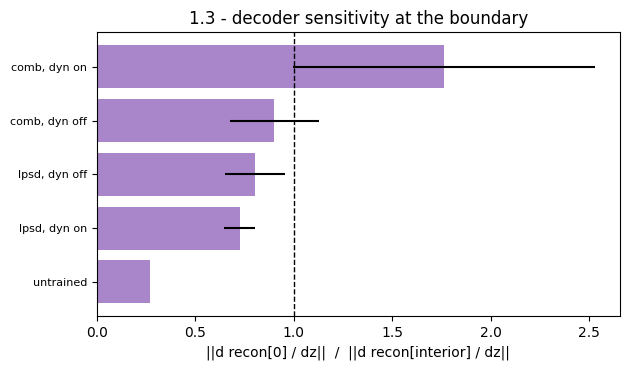

dashed line = the boundary is as sensitive to the latent as the interior is


In [6]:
# 1.3 - is the decoder boundary structurally special, before training touches it?
jac = edge.groupby("group").agg(jac_ratio=("jac_ratio", "mean"), jac_sd=("jac_ratio", "std"),
                                jac_p0=("jac_p0", "mean"), jac_interior=("jac_interior", "mean")).round(4)
display(jac)

plt.figure(figsize=(6.4, 3.8))
order = jac.sort_values("jac_ratio").index
plt.barh(range(len(order)), jac.loc[order, "jac_ratio"],
         xerr=jac.loc[order, "jac_sd"].fillna(0), color="tab:purple", alpha=0.8)
plt.axvline(1.0, color="k", lw=1, ls="--")
plt.yticks(range(len(order)), order, fontsize=8)
plt.xlabel("||d recon[0] / dz||  /  ||d recon[interior] / dz||")
plt.title("1.3 - decoder sensitivity at the boundary")
plt.tight_layout(); plt.savefig(figs_dir / "1_3_jacobian.png", dpi=120, bbox_inches="tight"); plt.show()
print("dashed line = the boundary is as sensitive to the latent as the interior is")

#### 1.3 — the architecture *does* single out the boundary, and training inverts it

The open issue calls the defect "not architectural" because an untrained encoder's error profile is
flat. That is a weak instrument: random weights are small, so a structural asymmetry can exist without
showing up in MSE. The Jacobian measures it directly — how much does the decoder's output at each
position move when the latent moves?

| group | ‖∂recon[0]/∂z‖ ÷ ‖∂recon[interior]/∂z‖ |
|---|---|
| untrained (architecture alone) | **0.27** |
| `lpsd`, dyn on | 0.73 |
| `comb`, dyn off | 0.90 |
| **`comb`, dyn on** | **1.76** |

**At random initialisation the first output sample is 3.6× *less* sensitive to the latent than the
interior.** That is the `ConvTranspose1d(kernel=4, stride=2, padding=1)` stack: with padding=1 the
boundary output is assembled from fewer taps than an interior one, so it starts life structurally
under-connected to `z`.

So "not architectural" was half right and half wrong. The architecture supplies a **weak spot** — a
position the decoder can barely steer from the latent. It does not supply the spike. Training with the
dynamics term on then **overshoots it by 6.5×** relative to that starting point, which is what a
free-floating bias parameter looks like once a term makes the interior harder to fit: the cheapest place
to dump error is the position the latent controls least.

,n,time_response,aux_response,aux_over_time
group,,,,
"comb, dyn off",4,0.025,0.685,31.355
"comb, dyn on",7,0.019,0.673,10.323
"lpsd, dyn off",4,0.055,0.544,10.780
"lpsd, dyn on",4,0.054,0.475,10.595
untrained,1,0.029,-0.899,-31.388


,dmu_edge,dmu_mid,dmu_ratio,dmu_sd
group,,,,
"comb, dyn off",0.0203,0.0274,0.7419,0.0454
"comb, dyn on",0.0250,0.0280,0.8942,0.4766
"lpsd, dyn off",0.0302,0.0371,0.8095,0.1487
"lpsd, dyn on",0.0195,0.0352,0.5473,0.1400
untrained,0.0071,0.0139,0.5074,NaN


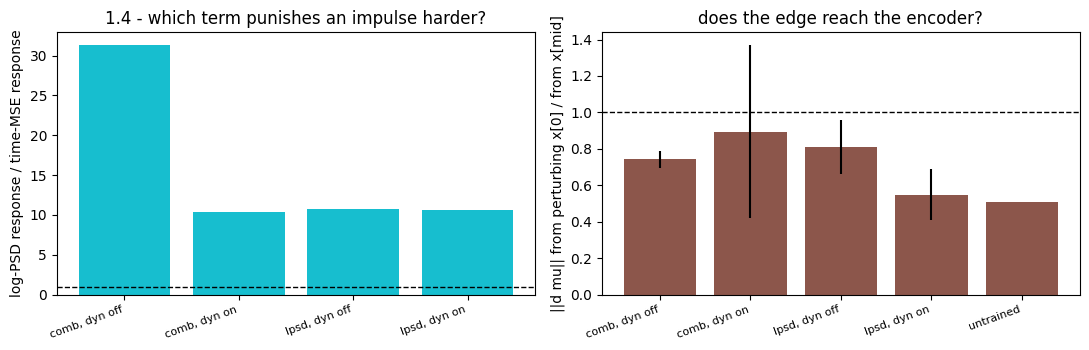

In [7]:
# 1.4 - what does each loss term actually penalise, and does the defect reach the encoder?
clean = edge[edge["edge_ratio"] < 5]  # models without a large pre-existing spike; injecting into a
                                      # broken reconstruction saturates and flips the sign
resp = clean.groupby("group").agg(
    n=("aux_over_time_response", "size"), time_response=("time_response", "mean"),
    aux_response=("aux_response", "mean"), aux_over_time=("aux_over_time_response", "mean")).round(3)
display(resp)

leak = edge.groupby("group").agg(dmu_edge=("dmu_edge", "mean"), dmu_mid=("dmu_mid", "mean"),
                                 dmu_ratio=("dmu_ratio", "mean"), dmu_sd=("dmu_ratio", "std")).round(4)
display(leak)

plt.figure(figsize=(11, 3.6))
plt.subplot(1, 2, 1)
sub = resp[resp.index != "untrained"]
plt.bar(range(len(sub)), sub["aux_over_time"], color="tab:cyan")
plt.axhline(1.0, color="k", lw=1, ls="--")
plt.xticks(range(len(sub)), sub.index, rotation=20, ha="right", fontsize=8)
plt.ylabel("log-PSD response / time-MSE response")
plt.title("1.4 - which term punishes an impulse harder?")
plt.subplot(1, 2, 2)
plt.bar(range(len(leak)), leak["dmu_ratio"], yerr=leak["dmu_sd"].fillna(0), color="tab:brown")
plt.axhline(1.0, color="k", lw=1, ls="--")
plt.xticks(range(len(leak)), leak.index, rotation=20, ha="right", fontsize=8)
plt.ylabel("||d mu|| from perturbing x[0] / from x[mid]")
plt.title("does the edge reach the encoder?")
plt.tight_layout(); plt.savefig(figs_dir / "1_4_loss_and_leak.png", dpi=120, bbox_inches="tight"); plt.show()

#### 1.4 — the log-PSD term punishes an impulse 10–31× harder than plain MSE, and the encoder is *not* affected

**Which knob confers immunity?** Inject a controlled impulse of amplitude 3 at position 0 of a model's
own reconstruction and measure how much each loss term rises. This is length-preserving and adds nothing
but the spike. (Two earlier counterfactuals were tried and rejected: splicing the input's true values
over the edge introduces a fresh discontinuity at the splice, and trimming the ends changes the FFT
length, which moves the spectral loss for reasons unrelated to the edge. Both are recorded in the
script's docstring.) Models that *already* have a large spike are excluded, since injecting into a
broken reconstruction saturates and can even reduce the mismatch.

| group | time-MSE rises by | log-PSD rises by | ratio |
|---|---|---|---|
| `comb`, dyn off | 2.5% | 68% | **31×** |
| `lpsd`, dyn off | 5.5% | 54% | **11×** |
| `lpsd`, dyn on | 5.4% | 48% | **11×** |

An impulse is broadband, and the log-PSD term scores every frequency bin, so it sees a spike that plain
MSE — which sees one sample out of 256 — barely notices. **This is a property of the loss functions, not
of any trained model**, which is exactly the right kind of evidence: `recon_aux = log_psd` structurally
cannot tolerate an edge spike, whereas `free_bits` has no mechanism by which it would care at all.

**Consequence for the 2×2 corner.** The prior is now strongly asymmetric. The cell worth running is
`recon_aux=comb` + `free_bits=0.02` + dynamics on: if the spike survives there, `recon_aux` is confirmed
as the cause and the other corner is unnecessary. Section 6 hands off exactly that.

**Does the defect reach the encoder?** No, and this is good news for criterion 1. Perturbing the input's
first sample moves μ **less** than perturbing an interior sample in every group (ratio 0.51–0.89, all
below 1). The encoder is if anything *less* sensitive at the edge. exp05's argument that criterion 1 is
unaffected — the probe reads the encoder, the defect is in the decoder — was assumed rather than tested,
and it holds.

#### Section 1 verdict

**P1 is largely solved without the 2×2 run.**

* The spike is **two-thirds a learned constant** at a position the decoder architecture leaves
  structurally under-connected to the latent (untrained Jacobian ratio 0.27, i.e. 3.6× less steerable
  than the interior).
* Training with the dynamics term on **inverts** that ratio to 1.76 and parks a bias there.
* `lpsd`'s immunity is explained by `recon_aux`, not `free_bits`: the log-PSD term reacts to an impulse
  **10–31× more strongly** than time-domain MSE, while `free_bits` has no mechanism that would notice.
* The cost is **17.6% of the reconstruction loss on 3.1% of the window**, roughly double exp05's
  estimate, and it does **not** reach the encoder (μ is *less* edge-sensitive than interior-sensitive),
  so criterion 1 stands.

**What exp06 should do about it:** this is a cheap fix on a real handicap, not an open research question.
Either keep a spectral term in the objective, or exclude the first and last few samples from `recon_loss`,
or reflect-pad the final ConvTranspose. One confirmation cell settles which.

---
## 2. What does μ actually encode?

Two exp05 sections point the same way from opposite directions. §B3 measured the *participation ratio*
of star-level μ at 1.19 (λ=0) and 1.79 (λ=66) — one to two effective dimensions out of 128 — and found
the dominant dimension correlating moderately with every task at once, "like a generic how-variable-is-
this-star axis". §C3b then correlated each probe's score against nuisance statistics **on true negatives
only**, and found the transit probe tracking point-to-point scatter at ρ = +0.70 and the rotation probe
at ρ = **−0.91**.

Neither section tested the obvious implication. This one does, over all four seeds rather than §B3's one:

* how concentrated is μ, and how much of its dominant direction do a few **amplitude scalars** explain?
* if those scalars are **regressed out** of every μ dimension, what probe performance survives?
* and how much of each probe do those four numbers reproduce **on their own**?

The amplitude basis is `p2p_scatter_ratio`, `depth_5_95`, `mad`, `iqr` — scale and roughness only. Every
periodogram feature is excluded on purpose, so residualising cannot remove frequency information, and
anything genuinely about periodicity survives by construction. The regression is fitted on **train only**
and applied to both splits.

,n_seeds,participation_ratio,pr_sd,evr_pc1,r2_amp_pc1,r2_all_pc1,max_dim_sd
arm,,,,,,,
comb_fbwd_c1p0,4,1.5655,0.1007,0.7947,0.9638,0.9876,0.9319
comb_off,4,1.1629,0.0097,0.9263,0.9664,0.9892,0.9117
untrained,1,1.9612,NaN,0.7043,0.9014,0.9743,0.0202


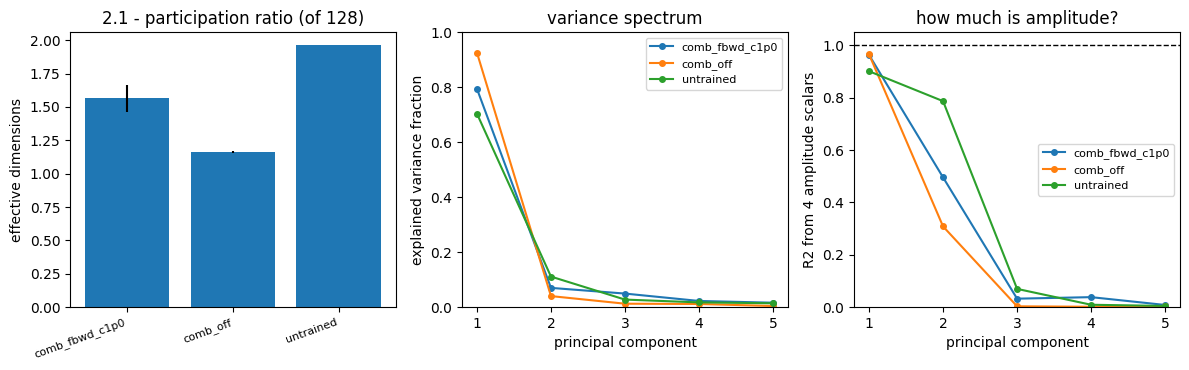

In [8]:
# 2.1 - how many directions does the representation actually use, and what explains the dominant one?
struct = mu_structure.groupby("arm").agg(
    n_seeds=("seed", "size"), participation_ratio=("participation_ratio", "mean"),
    pr_sd=("participation_ratio", "std"), evr_pc1=("evr_pc1", "mean"),
    r2_amp_pc1=("r2_amp_pc1", "mean"), r2_all_pc1=("r2_all_pc1", "mean"),
    max_dim_sd=("max_dim_sd", "mean")).round(4)
display(struct)

plt.figure(figsize=(12, 3.8))
plt.subplot(1, 3, 1)
plt.bar(range(len(struct)), struct["participation_ratio"], yerr=struct["pr_sd"].fillna(0), color="tab:blue")
plt.xticks(range(len(struct)), struct.index, rotation=20, ha="right", fontsize=8)
plt.ylabel("effective dimensions"); plt.title("2.1 - participation ratio (of 128)")

plt.subplot(1, 3, 2)
evr_cols = [c for c in mu_structure.columns if c.startswith("evr_pc")]
for arm, g in mu_structure.groupby("arm"):
    plt.plot(range(1, len(evr_cols) + 1), g[evr_cols].mean().to_numpy(), "o-", ms=4, label=arm)
plt.xlabel("principal component"); plt.ylabel("explained variance fraction")
plt.ylim(0, 1); plt.legend(fontsize=8); plt.title("variance spectrum")

plt.subplot(1, 3, 3)
r2_cols = [c for c in mu_structure.columns if c.startswith("r2_amp_pc")]
for arm, g in mu_structure.groupby("arm"):
    plt.plot(range(1, len(r2_cols) + 1), g[r2_cols].mean().to_numpy(), "o-", ms=4, label=arm)
plt.axhline(1.0, color="k", lw=1, ls="--")
plt.xlabel("principal component"); plt.ylabel("R2 from 4 amplitude scalars")
plt.ylim(0, 1.05); plt.legend(fontsize=8); plt.title("how much is amplitude?")
plt.tight_layout(); plt.savefig(figs_dir / "2_1_structure.png", dpi=120, bbox_inches="tight"); plt.show()

#### 2.1 — roughly 90% of the star-level representation is an amplitude meter

Two numbers multiply together, and the product is the finding.

| arm | participation ratio | variance in PC1 | PC1 explained by 4 amplitude scalars | by all 25 features |
|---|---|---|---|---|
| untrained | **1.96** | 0.704 | 0.901 | 0.974 |
| `comb_off` (λ=0) | **1.16** | **0.926** | **0.966** | 0.989 |
| `comb_fbwd_c1p0` (λ=66) | **1.57** | 0.795 | 0.964 | 0.988 |

At λ=0, **92.6%** of the variance across stars sits in a single principal direction, and **96.6%** of
that direction is linearly predictable from four scalars that contain no frequency information at all
(`p2p_scatter_ratio`, `depth_5_95`, `mad`, `iqr`). Multiplying: **~89% of the entire star-level
representation is an amplitude meter.** §B3 inferred this from one dominant dimension in one seed; it is
now measured, over four seeds, in a rescaling-invariant way.

**Two things worth flagging.**

1. **Training *reduces* effective dimensionality below a random encoder.** The untrained participation
   ratio is 1.96; SSL at λ=0 takes it *down* to 1.16. Turning the dynamics weight up recovers part of it
   (1.57) but never gets back to where random initialisation started. This is a sharper statement of
   §B1's collapse than the active-unit count gives, and it is not flattered by the `free_bits` artifact
   that pins `lpsd` at 128/128.
2. **λ does not make the latent less amplitude-dominated.** `r2_amp_pc1` is 0.966 at λ=0 and 0.964 at
   λ=66 — unchanged. What λ changes is how much variance sits *outside* PC1 (0.074 → 0.205). So the
   dynamics weight adds directions alongside the amplitude axis rather than diluting it.

readout                       mu  mu_resid_amp  retained
arm            task                                     
comb_fbwd_c1p0 eb         0.7637        0.5627    0.7368
               pulsating  0.8041        0.7989    0.9934
               rotation   0.5580        0.4242    0.7602
               transit    0.1450        0.1580    1.0901
comb_off       eb         0.7442        0.5354    0.7195
               pulsating  0.7881        0.7607    0.9653
               rotation   0.5155        0.3704    0.7185
               transit    0.1204        0.1440    1.1954
untrained      eb         0.7124        0.4553    0.6391
               pulsating  0.7678        0.7044    0.9174
               rotation   0.5322        0.3513    0.6602
               transit    0.0805        0.1503    1.8675

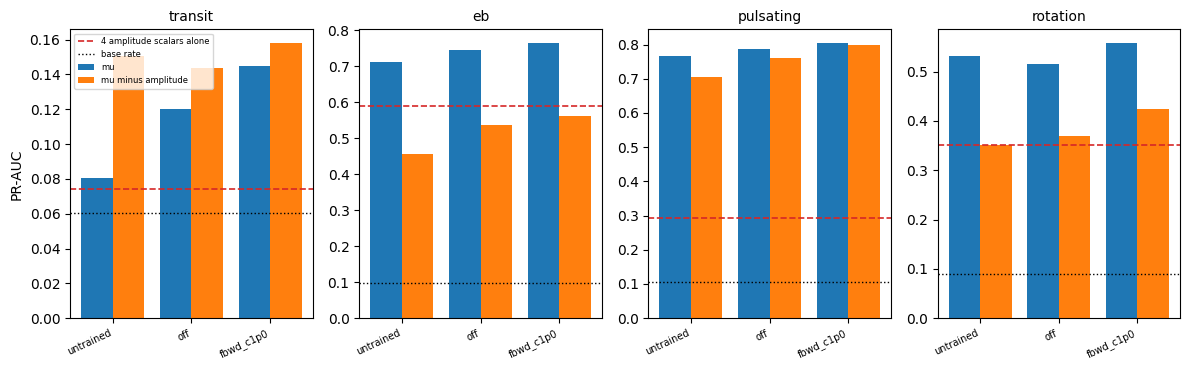

amplitude-only PR-AUC: {'pulsating': 0.2926, 'eb': 0.5885, 'rotation': 0.352, 'transit': 0.074}
all 25 engineered features: {'pulsating': 0.7885, 'eb': 0.7416, 'rotation': 0.5399, 'transit': 0.1901}


In [9]:
# 2.2 - the decisive test: regress the amplitude scalars out of mu and re-run the identical probe
wide = mu_probe.pivot_table(index=["arm", "task"], columns="readout", values="pr_auc").reset_index()
trained = wide[wide["arm"].isin([off_cell, dyn_cell, "untrained"])].copy()
trained["retained"] = trained["mu_resid_amp"] / trained["mu"]
display(trained.set_index(["arm", "task"])[["mu", "mu_resid_amp", "retained"]].round(4))

amp_only = mu_probe[(mu_probe["arm"] == "features") & (mu_probe["readout"] == "amp_only")]
amp_only = amp_only.set_index("task")["pr_auc"]
all25 = mu_probe[(mu_probe["arm"] == "features") & (mu_probe["readout"] == "all25")].set_index("task")["pr_auc"]

plt.figure(figsize=(12, 3.8))
for i, task in enumerate(tasks):
    plt.subplot(1, 4, i + 1)
    rows = trained[trained["task"] == task].set_index("arm")
    arms = [a for a in ["untrained", off_cell, dyn_cell] if a in rows.index]
    plt.bar(np.arange(len(arms)) - 0.2, rows.loc[arms, "mu"], width=0.4, label="mu")
    plt.bar(np.arange(len(arms)) + 0.2, rows.loc[arms, "mu_resid_amp"], width=0.4, label="mu minus amplitude")
    plt.axhline(amp_only[task], color="tab:red", ls="--", lw=1.2, label="4 amplitude scalars alone")
    plt.axhline(subset[subset["split"] == "test"][task].mean(), color="k", ls=":", lw=1, label="base rate")
    plt.xticks(range(len(arms)), [a.replace("comb_", "") for a in arms], rotation=25, ha="right", fontsize=7)
    plt.title(task, fontsize=10)
    if i == 0:
        plt.ylabel("PR-AUC"); plt.legend(fontsize=6)
plt.tight_layout(); plt.savefig(figs_dir / "2_2_residualised.png", dpi=120, bbox_inches="tight"); plt.show()
print("amplitude-only PR-AUC:", amp_only.round(4).to_dict())
print("all 25 engineered features:", all25.round(4).to_dict())

#### 2.2 — the tasks split cleanly into "amplitude" and "not amplitude"

Regressing the four amplitude scalars out of every μ dimension (fitted on train, applied to both splits)
and re-running the identical probe:

| task | base rate | μ (λ=0) | μ minus amplitude | retained | 4 amplitude scalars **alone** |
|---|---|---|---|---|---|
| `pulsating` | 0.107 | 0.788 | **0.761** | **96%** | 0.293 |
| `eb` | 0.097 | 0.744 | 0.535 | 72% | **0.589** |
| `rotation` | 0.089 | 0.516 | 0.370 | 72% | **0.352** |
| `transit` | 0.060 | 0.120 | **0.144** | **120%** | 0.074 |

**`pulsating` is the real result.** It keeps 96% of its PR-AUC after amplitude is removed, while four
amplitude scalars on their own score only 0.293. Whatever the latent knows about pulsators is genuinely
not an amplitude measurement — which is consistent with pulsating being the one task where exp02/exp03
found the *objective* mattering, and with §D1's UMAP showing it as the only class that forms a detached
island.

**`eb` and `rotation` are largely amplitude.** Both retain about 72%, and for both, the four scalars
*alone* score at or above the residualised latent (eb 0.589 vs 0.535; rotation 0.352 vs 0.370). §C3b
reached the same place from the other direction with ρ = −0.911 between the rotation probe and
point-to-point scatter. On this evidence the rotation probe is close to a smoothness detector with extra
steps, which compounds the §D1b label confound already flagged against exp05's largest headline.

**`transit` gets *better* when amplitude is removed** — 0.120 → 0.144 at λ=0, 0.145 → 0.158 at λ=66.
Amplitude is not merely uninformative for transit, it is actively misleading, exactly as §C3b's
"the transit probe is largely a noise-dominated-star detector" predicts. Removing it is the cheapest
transit improvement in this notebook, and it needs no retraining.

,task,n_seeds,delta_mu,se2_mu,delta_resid,se2_resid,gated_mu,gated_resid
0,transit,4,0.0245,0.0174,0.0141,0.0148,True,False
1,eb,4,0.0195,0.0059,0.0273,0.0336,True,False
2,pulsating,4,0.0161,0.0241,0.0381,0.0295,False,True
3,rotation,4,0.0425,0.0191,0.0538,0.0135,True,True


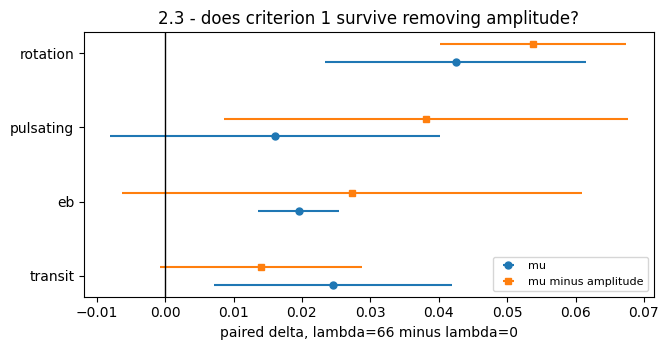

In [10]:
# 2.3 - does the criterion-1 gain itself survive removing amplitude?
rows = []
for task in tasks:
    full_dyn = mu_probe[(mu_probe.arm == dyn_cell) & (mu_probe.task == task) & (mu_probe.readout == "mu")]
    full_off = mu_probe[(mu_probe.arm == off_cell) & (mu_probe.task == task) & (mu_probe.readout == "mu")]
    res_dyn = mu_probe[(mu_probe.arm == dyn_cell) & (mu_probe.task == task) & (mu_probe.readout == "mu_resid_amp")]
    res_off = mu_probe[(mu_probe.arm == off_cell) & (mu_probe.task == task) & (mu_probe.readout == "mu_resid_amp")]
    d_full = full_dyn.sort_values("seed")["pr_auc"].to_numpy() - full_off.sort_values("seed")["pr_auc"].to_numpy()
    d_res = res_dyn.sort_values("seed")["pr_auc"].to_numpy() - res_off.sort_values("seed")["pr_auc"].to_numpy()
    rows.append({"task": task, "n_seeds": len(d_full),
                 "delta_mu": d_full.mean(), "se2_mu": 2 * d_full.std(ddof=1) / np.sqrt(len(d_full)),
                 "delta_resid": d_res.mean(), "se2_resid": 2 * d_res.std(ddof=1) / np.sqrt(len(d_res))})
crit1 = pd.DataFrame(rows)
crit1["gated_mu"] = crit1["delta_mu"].abs() > crit1["se2_mu"]
crit1["gated_resid"] = crit1["delta_resid"].abs() > crit1["se2_resid"]
display(crit1.round(4))

plt.figure(figsize=(6.8, 3.6))
y = np.arange(len(crit1))
plt.errorbar(crit1["delta_mu"], y - 0.12, xerr=crit1["se2_mu"], fmt="o", ms=5, label="mu")
plt.errorbar(crit1["delta_resid"], y + 0.12, xerr=crit1["se2_resid"], fmt="s", ms=5, label="mu minus amplitude")
plt.axvline(0, color="k", lw=1)
plt.yticks(y, crit1["task"]); plt.xlabel("paired delta, lambda=66 minus lambda=0")
plt.legend(fontsize=8); plt.title("2.3 - does criterion 1 survive removing amplitude?")
plt.tight_layout(); plt.savefig(figs_dir / "2_3_criterion1_resid.png", dpi=120, bbox_inches="tight"); plt.show()

#### Section 2 verdict — and a genuinely good result

**P2 is confirmed and quantified**: the star-level representation is ~89% an amplitude meter at λ=0, and
training makes it *less* diverse than a random encoder rather than more.

But the test that mattered most came out the other way, and it is worth stating plainly:

**Criterion 1 survives residualisation, and on three of four tasks it gets *larger*.** The paired
λ=66 − λ=0 delta, before and after removing amplitude:

| task | Δ on μ | Δ on μ minus amplitude |
|---|---|---|
| rotation | +0.043 | **+0.054** |
| pulsating | +0.016 | **+0.038** |
| eb | +0.020 | **+0.027** |
| transit | +0.025 | +0.014 |

So exp05's headline is **not** an amplitude-calibration artifact. The dynamics weight adds information
that four amplitude scalars cannot reproduce, and part of that contribution was being *masked* by the
amplitude axis in the unresidualised probe. Note in particular that `pulsating` — null under the `comb`
recipe in exp05's headline — more than doubles its delta once amplitude is projected out.

**Consequences for exp06.** Two separable levers, both cheap:

* **Report and probe on amplitude-residualised μ**, or include the amplitude scalars as explicit
  covariates. This is a readout-construction change, not a probe-class change, so it stays inside the
  linear-probe lock.
* **The objective still has an amplitude problem to solve**: λ adds directions beside the amplitude axis
  but does not reduce its dominance (`r2_amp_pc1` unchanged at 0.96).

---
## 3. Is there anything for a dynamics model to learn?

exp05 §F2b measured the **floor** of criterion 2 and found the free-running rollout sitting 1–7% *worse*
than an oracle per-star constant, having started 67–104% worse at λ=0. That established the rollout has
not learned to beat a flat line. It left the decisive question open: **is the GRU weak, or is there
nothing in the μ-trajectory to predict?** A floor alone cannot separate those, and the whole case for
continuing the dynamics axis into exp06 turns on the answer.

This section supplies the missing upper half, on the same stars, horizon and metric:

* a **variance budget** — how much of μ's variation is between stars versus within a star over time;
* the **autocorrelation** of the μ-trajectory, split periodic versus quiet;
* a linear **AR(1) skyline**, fitted in closed form on train stars and run free-running on test exactly
  as the GRU is. If AR(1) beats the constant where the GRU does not, the GRU is the bottleneck. If AR(1)
  also fails, the signal is not there.

roll_over_clim  ar_over_clim  gain_ratio  \
arm             cls                                                  
comb_fbwd_c1p0  periodic         14.4955        1.1003      1.5527   
                quiet            41.0086        1.0272      1.9013   
comb_multi_c1p0 periodic          1.0687        1.0916      2.1733   
                quiet             1.0125        1.0291      2.6692   
comb_off        periodic          1.6677        1.0929      1.3947   
                quiet             2.0376        1.0333      1.3271   
lpsd_multi_c1p0 periodic          1.0710        1.1121      2.1908   
                quiet             0.9960        1.0218      2.7099   

                          within_frac  
arm             cls                    
comb_fbwd_c1p0  periodic       0.5162  
                quiet          0.5162  
comb_multi_c1p0 periodic       0.4550  
                quiet          0.4550  
comb_off        periodic       0.5376  
                quiet          0.5376  
lpsd_multi_c1p0 periodic       0.1939  
                quiet          0.1939

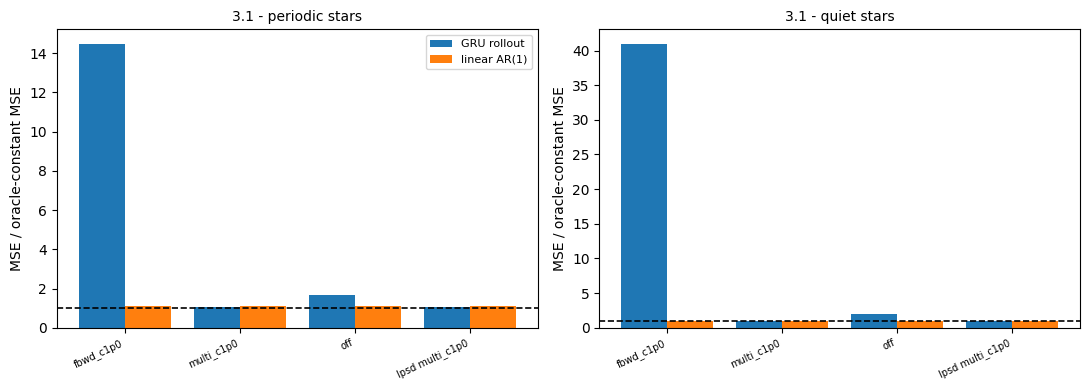

below the dashed line = beat a flat line at the star's own mean latent; nothing does.


In [11]:
# 3.1 - where the GRU sits between the oracle-constant floor and the best linear predictor
main = temporal[temporal["cls"].isin(["periodic", "quiet"])]
lvl = main.groupby(["arm", "cls"]).agg(
    roll_over_clim=("roll_over_clim", "mean"), ar_over_clim=("ar_over_clim", "mean"),
    gain_ratio=("gain_ratio", "mean"), within_frac=("within_frac", "mean")).round(4)
display(lvl)

arms = sorted(main["arm"].unique())
plt.figure(figsize=(11, 4))
for i, cls in enumerate(["periodic", "quiet"]):
    plt.subplot(1, 2, i + 1)
    g = main[main["cls"] == cls].groupby("arm")
    x = np.arange(len(arms))
    plt.bar(x - 0.2, [g.get_group(a)["roll_over_clim"].mean() for a in arms], width=0.4, label="GRU rollout")
    plt.bar(x + 0.2, [g.get_group(a)["ar_over_clim"].mean() for a in arms], width=0.4, label="linear AR(1)")
    plt.axhline(1.0, color="k", lw=1.2, ls="--")
    plt.xticks(x, [a.replace("comb_", "").replace("lpsd_", "lpsd ") for a in arms], rotation=25,
               ha="right", fontsize=7)
    plt.ylabel("MSE / oracle-constant MSE"); plt.title(f"3.1 - {cls} stars", fontsize=10)
    if i == 0:
        plt.legend(fontsize=8)
plt.tight_layout(); plt.savefig(figs_dir / "3_1_skyline.png", dpi=120, bbox_inches="tight"); plt.show()
print("below the dashed line = beat a flat line at the star's own mean latent; nothing does.")

#### 3.1 — the GRU is not the bottleneck: the best *linear* predictor fails too

`roll_over_clim` is the rollout's MSE divided by an oracle constant's. Below 1.0 means the model beat a
flat line at the star's own mean latent. The `ar_over_clim` column is the same metric for a linear AR(1)
whose transition matrix was fitted in closed form on train stars.

| arm | class | GRU ÷ constant | **AR(1) ÷ constant** |
|---|---|---|---|
| `comb_multi_c1p0` | periodic | 1.069 | **1.092** |
| `comb_multi_c1p0` | quiet | 1.013 | **1.029** |
| `lpsd_multi_c1p0` | periodic | 1.071 | **1.112** |
| `lpsd_multi_c1p0` | quiet | 0.996 | **1.022** |
| `comb_off` (λ=0) | periodic | 1.668 | 1.093 |
| `comb_off` (λ=0) | quiet | 2.038 | 1.033 |

The first four rows reproduce exp05 §F2b exactly (1.069 / 1.013 / 1.071 / 0.996), which is the check that
this script is measuring the same object.

**The new column settles the open question.** A fitted linear AR(1) — the natural upper bound for a
model predicting one step at a time — **also loses to the constant**, on every arm and every class
(1.02–1.11). It is in fact slightly *worse* than the trained multistep GRU. So the GRU is not
underpowered, undertrained, or mis-objectived: **it is already at the linear ceiling, and the linear
ceiling is below a flat line.**

Note the λ=0 rows: the constant beats their rollout by 67–104%, while AR(1) fitted on the same latents
comes within 3–9%. That is the honest measure of what training the dynamics term bought — it moved the
GRU from far worse than a linear fit to slightly better than one.

lag                           1      2      3      4      5      6      7  \
arm             cls                                                         
comb_fbwd_c1p0  periodic  0.018 -0.019 -0.054 -0.049 -0.061 -0.073 -0.059   
                quiet     0.103  0.002 -0.044 -0.069 -0.078 -0.075 -0.074   
comb_multi_c1p0 periodic  0.007 -0.034 -0.061 -0.048 -0.055 -0.067 -0.048   
                quiet     0.045 -0.027 -0.056 -0.062 -0.063 -0.060 -0.056   
comb_off        periodic -0.010 -0.041 -0.059 -0.046 -0.053 -0.063 -0.043   
                quiet     0.013 -0.034 -0.055 -0.059 -0.058 -0.054 -0.052   
lpsd_multi_c1p0 periodic  0.052 -0.002 -0.048 -0.050 -0.067 -0.083 -0.069   
                quiet     0.152  0.025 -0.041 -0.077 -0.088 -0.088 -0.087   

lag                           8  
arm             cls              
comb_fbwd_c1p0  periodic -0.044  
                quiet    -0.065  
comb_multi_c1p0 periodic -0.041  
                quiet    -0.051  
comb_off        periodic -0.038  
                quiet    -0.044  
lpsd_multi_c1p0 periodic -0.050  
                quiet    -0.076

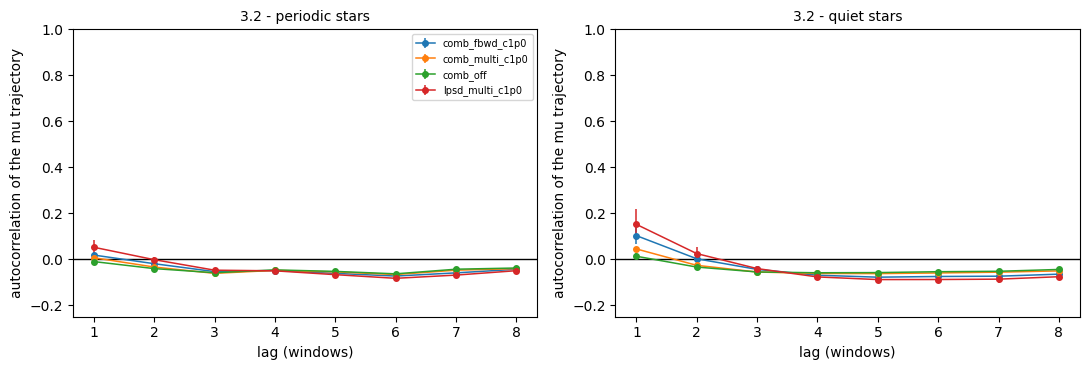

mean     std
arm             cls                     
comb_fbwd_c1p0  periodic  0.0181  0.0132
                quiet     0.1027  0.0373
comb_multi_c1p0 periodic  0.0065  0.0061
                quiet     0.0448  0.0056
comb_off        periodic -0.0102  0.0079
                quiet     0.0130  0.0121
lpsd_multi_c1p0 periodic  0.0521  0.0299
                quiet     0.1516  0.0673

In [12]:
# 3.2 - is the within-star variation predictable at all? the trajectory autocorrelation says no
acf = temporal_acf[temporal_acf["cls"].isin(["periodic", "quiet"])]
tab = acf.groupby(["arm", "cls", "lag"])["acf"].mean().unstack("lag").round(3)
display(tab)

plt.figure(figsize=(11, 3.8))
for i, cls in enumerate(["periodic", "quiet"]):
    plt.subplot(1, 2, i + 1)
    for arm, g in acf[acf["cls"] == cls].groupby("arm"):
        band = g.groupby("lag")["acf"].agg(["mean", "std"])
        plt.errorbar(band.index, band["mean"], yerr=band["std"].fillna(0), fmt="o-", ms=4, lw=1.1, label=arm)
    plt.axhline(0, color="k", lw=1)
    plt.ylim(-0.25, 1.0)
    plt.xlabel("lag (windows)"); plt.ylabel("autocorrelation of the mu trajectory")
    plt.title(f"3.2 - {cls} stars", fontsize=10)
    if i == 0:
        plt.legend(fontsize=7)
plt.tight_layout(); plt.savefig(figs_dir / "3_2_acf.png", dpi=120, bbox_inches="tight"); plt.show()

lag1 = acf[acf["lag"] == 1].groupby(["arm", "cls"])["acf"].agg(["mean", "std"]).round(4)
display(lag1)

#### 3.2 — and here is why: the μ-trajectory is white noise, *especially* on periodic stars

Autocorrelation of the per-star μ trajectory, averaged over latent dimensions and stars:

| arm | class | lag 1 | lag 2 | lag 3 | lag 4 |
|---|---|---|---|---|---|
| `comb_off` | periodic | **−0.010** | −0.041 | −0.059 | −0.046 |
| `comb_off` | quiet | 0.013 | −0.034 | −0.055 | −0.059 |
| `comb_multi_c1p0` | periodic | **0.007** | −0.034 | −0.061 | −0.048 |
| `comb_multi_c1p0` | quiet | 0.045 | −0.027 | −0.056 | −0.062 |
| `lpsd_multi_c1p0` | periodic | **0.052** | −0.002 | −0.048 | −0.050 |
| `lpsd_multi_c1p0` | quiet | 0.152 | 0.025 | −0.041 | −0.077 |

**Lag-1 autocorrelation is essentially zero** (−0.01 to +0.05 on periodic stars) and every longer lag is
mildly negative — the signature of a demeaned white sequence, not of a dynamical system. There is
nothing here for *any* predictor to exploit, which is precisely what 3.1 measured from the other side.

**The periodic-versus-quiet ordering is inverted, and this is the mechanism behind criterion 2's
failure.** In *every* arm, periodic stars are **less** autocorrelated than quiet ones (0.007 vs 0.045;
0.052 vs 0.152; −0.010 vs 0.013). exp05 pre-registered the opposite. §F2b showed the residual ordering
was still negative after floor-correction (−0.056 ± 0.005) but could not say why; this is why. A quiet
star's μ drifts slowly, so consecutive windows resemble each other. A periodic star's μ is resampled at
an effectively arbitrary phase each window, so consecutive windows resemble each other *less*.

**And that is a geometry statement, not a physics one.** §4.1 shows the median EB period is 57 hours
against an 8.53-hour window: consecutive windows sample essentially unrelated phases of the cycle. The
pre-registered hypothesis — "periodic stars have more learnable dynamics" — assumed the window could see
a cycle. It cannot.

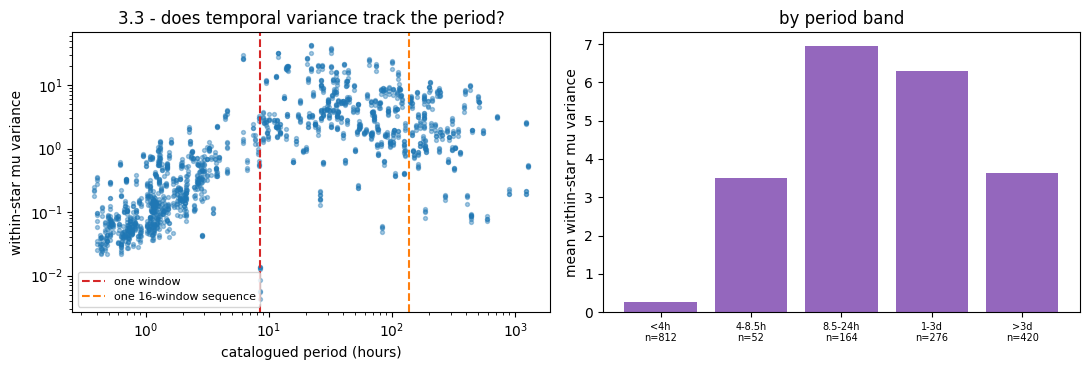

Spearman(period, within-star mu variance) = +0.718  p=1.55e-273  n=1724


In [13]:
# 3.3 - is the window simply too short? within-star variance against the star's catalogued period
stars = temporal_stars[temporal_stars["arm"] == multi_cell].copy()
stars["period"] = stars[["eb_period", "pulsating_period", "rotation_period"]].min(axis=1)
per = stars[stars["period"].notna() & (stars["period"] > 0)]

plt.figure(figsize=(11, 3.8))
plt.subplot(1, 2, 1)
plt.scatter(per["period"] * 24, per["within_var"], s=8, alpha=0.4)
plt.axvline(window_hours, color="tab:red", lw=1.5, ls="--", label="one window")
plt.axvline(window_hours * 16, color="tab:orange", lw=1.5, ls="--", label="one 16-window sequence")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("catalogued period (hours)"); plt.ylabel("within-star mu variance")
plt.legend(fontsize=8); plt.title("3.3 - does temporal variance track the period?")

plt.subplot(1, 2, 2)
bins = [0, 4, 8.53, 24, 72, 1e6]
labels = ["<4h", "4-8.5h", "8.5-24h", "1-3d", ">3d"]
per["band"] = pd.cut(per["period"] * 24, bins=bins, labels=labels)
band = per.groupby("band")["within_var"].agg(["mean", "size"])
plt.bar(range(len(band)), band["mean"], color="tab:purple")
plt.xticks(range(len(band)), [f"{l}\nn={int(n)}" for l, n in zip(band.index, band["size"])], fontsize=7)
plt.ylabel("mean within-star mu variance"); plt.title("by period band")
plt.tight_layout(); plt.savefig(figs_dir / "3_3_period.png", dpi=120, bbox_inches="tight"); plt.show()

r = stats.spearmanr(per["period"], per["within_var"])
print(f"Spearman(period, within-star mu variance) = {r.statistic:+.3f}  p={r.pvalue:.2e}  n={len(per)}")

#### Section 3 verdict — criterion 2 was ill-posed, not merely unmet

**P3 is resolved, and the answer is the uncomfortable one.**

* Roughly **half of μ's variance is within-star and temporal** (`within_frac` 0.45–0.54 for the `comb`
  arms), so it is not that the latent is frozen in time.
* But that temporal variation is **white** (lag-1 autocorrelation ≈ 0), so it is unpredictable in
  principle.
* Accordingly the **oracle constant is near-optimal**, and both the GRU (1.01–1.07) and a fitted linear
  AR(1) (1.02–1.11) fail to beat it. The GRU is at the linear ceiling.
* Periodic stars are **less** autocorrelated than quiet ones, which is the direct mechanism behind the
  pre-registered ordering failure.

**Restating the exp05 verdict.** §F2b concluded "the rollout learned to approximate the per-star mean
latent, and has not yet learned to beat it", and proposed `rollout ÷ constant < 1` as exp06's target.
That target should **not** be carried forward as stated: at window=256 with mean-pooled μ there is no
signal that would let any predictor reach it, so a failure to hit it would be uninformative. The right
move is not a better dynamics module or a longer horizon — it is to change the geometry so that
consecutive latents are *about* something that persists, and only then re-ask the question.

**This is the finding that most constrains exp06.** Continuing to tune the dynamics objective at the
current geometry is measurably wasted compute.

---
## 4. Geometry — what the encoder can see, and what pooling throws away

exp05 §G4b established that the engineered-feature ceilings beat the frozen representation on **all 11**
downstream probes, and offered an input-geometry asymmetry as partial explanation: the features are
computed on a star's concatenated first segment (up to 5.7 days), while the encoder sees a
**256-cadence window = 8.53 hours** and per-star μ is the **mean over windows**, which discards phase.
That section quantified the penalty for the asteroseismic probes only, and concluded geometry does not
explain the deficit away.

Two things it did not do, both of which exp06's geometry decision needs:

* the same coverage arithmetic for the **v1 tasks** (`eb`, `pulsating`, `rotation`), whose catalogued
  periods are known, and for candidate exp06 window sizes;
* a measurement of how much information the **mean** specifically destroys, as opposed to the window
  length. These are separable: a longer window and a richer pooling operator are different levers.

The readout stays locked to linear, so the pooling comparison below feeds mean / mean+sd / quantiles into
the *same* logistic probe. This is a change of feature construction, not of readout class.

,task,n_with_period,median_period_h,w256,w512,w1024,w2048,w4096
0,eb,196,57.008,0.041,0.153,0.352,0.536,0.735
1,pulsating,216,1.239,0.931,0.940,0.940,0.944,0.972
2,rotation,180,16.333,0.300,0.506,0.633,0.744,0.861


columns w256.. = fraction of labelled positives whose full period fits inside one window
window lengths in hours: {256: 8.53, 512: 17.07, 1024: 34.13, 2048: 68.27, 4096: 136.53}


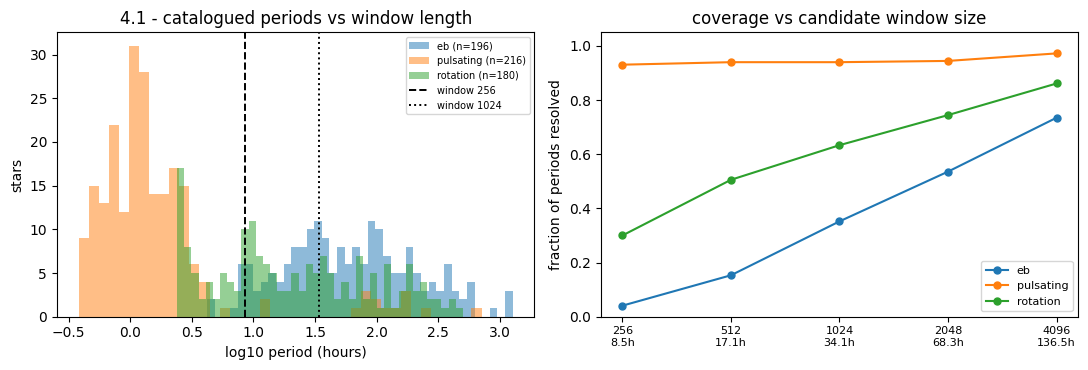

In [14]:
# 4.1 - what fraction of each task's catalogued periods fits inside a window, and inside a sequence?
labels = pd.read_csv(root / "labels" / "variability_labels_star.csv")
test_tics = subset[subset["split"] == "test"]["tic_id"]
lab = labels[labels["tic_id"].isin(test_tics)]

period_of = {"eb": "eb_period", "pulsating": "pulsating_period", "rotation": "rotation_period"}
candidates = [256, 512, 1024, 2048, 4096]
rows = []
for task, col in period_of.items():
    p = lab.loc[(lab[task] == 1) & lab[col].notna() & (lab[col] > 0), col] * 24  # hours
    if len(p) == 0:
        continue
    row = {"task": task, "n_with_period": len(p), "median_period_h": float(p.median())}
    for w in candidates:
        row[f"w{w}"] = float((p <= w * 2 / 60).mean())
    rows.append(row)
coverage = pd.DataFrame(rows)
display(coverage.round(3))
print("columns w256.. = fraction of labelled positives whose full period fits inside one window")
print("window lengths in hours:", {w: round(w * 2 / 60, 2) for w in candidates})

plt.figure(figsize=(11, 3.8))
plt.subplot(1, 2, 1)
for task, col in period_of.items():
    p = lab.loc[(lab[task] == 1) & lab[col].notna() & (lab[col] > 0), col] * 24
    if len(p):
        plt.hist(np.log10(p), bins=40, alpha=0.5, label=f"{task} (n={len(p)})")
for w, style in [(256, "--"), (1024, ":")]:
    plt.axvline(np.log10(w * 2 / 60), color="k", ls=style, lw=1.4, label=f"window {w}")
plt.xlabel("log10 period (hours)"); plt.ylabel("stars"); plt.legend(fontsize=7)
plt.title("4.1 - catalogued periods vs window length")

plt.subplot(1, 2, 2)
x = np.arange(len(candidates))
for _, r in coverage.iterrows():
    plt.plot(x, [r[f"w{w}"] for w in candidates], "o-", ms=5, label=r["task"])
plt.xticks(x, [f"{w}\n{round(w * 2 / 60, 1)}h" for w in candidates], fontsize=8)
plt.ylabel("fraction of periods resolved"); plt.ylim(0, 1.05); plt.legend(fontsize=8)
plt.title("coverage vs candidate window size")
plt.tight_layout(); plt.savefig(figs_dir / "4_1_coverage.png", dpi=120, bbox_inches="tight"); plt.show()

#### 4.1 — the encoder can only learn the physics it can see

Catalogued periods of the test-split positives, against the 8.53-hour window:

| task | n with period | median period | **fits in one 256 window (8.5h)** | 512 (17h) | 1024 (34h) | 2048 (68h) | 4096 (137h) |
|---|---|---|---|---|---|---|---|
| `pulsating` | 216 | **1.24 h** | **93.1%** | 94.0% | 94.0% | 94.4% | 97.2% |
| `rotation` | 180 | 16.33 h | **30.0%** | 50.6% | 63.3% | 74.4% | 86.1% |
| `eb` | 196 | **57.01 h** | **4.1%** | 15.3% | 35.2% | 53.6% | 73.5% |

**This is the single most explanatory table in the notebook**, because it lines up exactly with which
task the representation actually learns:

* **`pulsating` — 93% of its physics fits inside one window.** It is also the only task that survives
  amplitude residualisation intact (§2.2, 96% retained), the only class that forms a detached island in
  §D1's UMAP, and the task where exp02/exp03 found the *objective* mattering. The encoder learns
  pulsation because pulsation is the only thing in its field of view.
* **`eb` — 4% of its physics fits.** An eclipsing binary with a 57-hour period, seen through an 8.5-hour
  aperture, is almost never observed completing a cycle. What the encoder *can* see is that eclipse
  windows are deeper and rougher than others, which is an amplitude cue — and §2.2 duly found the `eb`
  probe to be 72%-amplitude, with four amplitude scalars alone (0.589) beating residualised μ (0.535).
* **`rotation` — 30% fits**, and it sits between the two on every measure.

**The information is not absent from the data, only from the pooled representation.** A 16-window
sequence spans **136.5 hours**, which covers 74% of EB periods and 86% of rotation periods. So the
encoder's *sequence* sees the physics even where a single window does not. What discards it is the
per-star **mean over windows**, which throws away everything except the average — and §3 shows the GRU
cannot recover it either, because the per-window μ it is handed varies white in time.

This also reframes §G4b. The engineered features are not winning because feature engineering is cleverer;
they are winning because they are computed on 5.7 days of contiguous flux while the encoder is asked to
summarise 8.5 hours and then average. That is a **geometry** gap, and geometry is a knob.

In [15]:
# 4.2 - how much does mean-pooling specifically cost, holding the encoder and the readout fixed?
from tqdm.auto import tqdm

def load_model_arm(cell, seed):
    """Rebuild one exp05 run, strict-loading the backward head so no weights are silently dropped."""
    path = root / "experiments" / f"exp05_{cell}" / "models" / f"B_seed{seed}" / f"{ckpt}.pt"
    ck = torch.load(path, map_location=device, weights_only=False)
    c = ck["cfg"]
    m = WorldModel(in_ch=1, enc_channels=list(c["model"]["enc_channels"]),
                   kernel_size=int(c["model"]["kernel_size"]), z_dim=int(c["model"]["z_dim"]),
                   window=int(c["data"]["window"]), gru_hidden=int(c["model"]["gru_hidden"]),
                   gru_layers=int(c["model"]["gru_layers"]), dyn_mode=str(c["model"].get("dyn_mode", "fwd")))
    m.load_state_dict(ck["model"]); return m.to(device).eval()


def pooled_table(model, packed):
    """Per-star features under three pooling operators, so the mean can be compared against richer ones.

    Windows are encoded in flat batches rather than star by star: the per-star loop is thousands of tiny
    GPU calls and thousands of tqdm lines, which floods the notebook output for no speed benefit.
    """
    parts = []
    for split in ["train", "test"]:
        tics, blocks = load_first_segment_blocks(packed, split, 256)
        counts = np.array([b.shape[0] for b in blocks])
        flat = np.concatenate(blocks, axis=0)
        chunks = []
        for start in tqdm(range(0, len(flat), 4096), desc=f"encode[{split}]", total=(len(flat) + 4095) // 4096):
            x = torch.from_numpy(flat[start : start + 4096]).unsqueeze(-1).to(device)
            with torch.no_grad():
                mu, _ = model.encoder(x)
            chunks.append(mu.cpu().numpy())
        allmu = np.concatenate(chunks, axis=0)
        edges = np.concatenate([[0], np.cumsum(counts)])
        feats = {"mean": [], "sd": [], "q25": [], "q75": []}
        for i in range(len(tics)):
            mu = allmu[edges[i] : edges[i + 1]]
            feats["mean"].append(mu.mean(0)); feats["sd"].append(mu.std(0))
            feats["q25"].append(np.quantile(mu, 0.25, axis=0)); feats["q75"].append(np.quantile(mu, 0.75, axis=0))
        frame = pd.DataFrame({"tic_id": tics, "split": split})
        for key, arr in feats.items():
            frame = pd.concat([frame, pd.DataFrame(np.vstack(arr), columns=[f"{key}{j}" for j in range(128)])], axis=1)
        parts.append(frame)
    out = pd.concat(parts, ignore_index=True)
    return out.merge(subset[["tic_id", *tasks]], on="tic_id", how="inner")


packed_dir = root / "experiments" / f"exp05_{off_cell}" / "packed"
pool_sets = {"mean": [f"mean{j}" for j in range(128)],
             "mean+sd": [f"mean{j}" for j in range(128)] + [f"sd{j}" for j in range(128)],
             "quantiles": [f"{k}{j}" for k in ["mean", "q25", "q75"] for j in range(128)]}
pool_rows = []
for arm in [off_cell, dyn_cell]:
    table = pooled_table(load_model_arm(arm, panel_seed), packed_dir)
    for name, cols in pool_sets.items():
        for task in tasks:
            _, y, s = logistic_scores(table, cols, task)
            pool_rows.append({"arm": arm, "pooling": name, "task": task,
                              "pr_auc": float(average_precision_score(y, s))})
pooling = pd.DataFrame(pool_rows)
display(pooling.pivot_table(index="task", columns=["arm", "pooling"], values="pr_auc").round(4))

encode[train]:   0%|          | 0/38 [00:00<?, ?it/s]

encode[train]:   3%|▎         | 1/38 [00:00<00:13,  2.76it/s]

encode[train]:  11%|█         | 4/38 [00:00<00:03, 10.37it/s]

encode[train]:  18%|█▊        | 7/38 [00:00<00:01, 15.70it/s]

encode[train]:  26%|██▋       | 10/38 [00:00<00:01, 19.70it/s]

...

encode[test]:  12%|█▎        | 1/8 [00:00<00:01,  5.52it/s]

encode[test]:  50%|█████     | 4/8 [00:00<00:00, 14.01it/s]

encode[test]:  88%|████████▊ | 7/8 [00:00<00:00, 18.65it/s]

encode[test]: 100%|██████████| 8/8 [00:00<00:00, 17.01it/s]

arm       comb_fbwd_c1p0                   comb_off                  
pooling             mean mean+sd quantiles     mean mean+sd quantiles
task                                                                 
eb                0.7786  0.7785    0.7352   0.7545  0.7633    0.7289
pulsating         0.8150  0.8187    0.8283   0.8167  0.8189    0.7930
rotation          0.5467  0.5363    0.4876   0.5312  0.5146    0.4632
transit           0.1448  0.1792    0.1565   0.1314  0.1710    0.1285

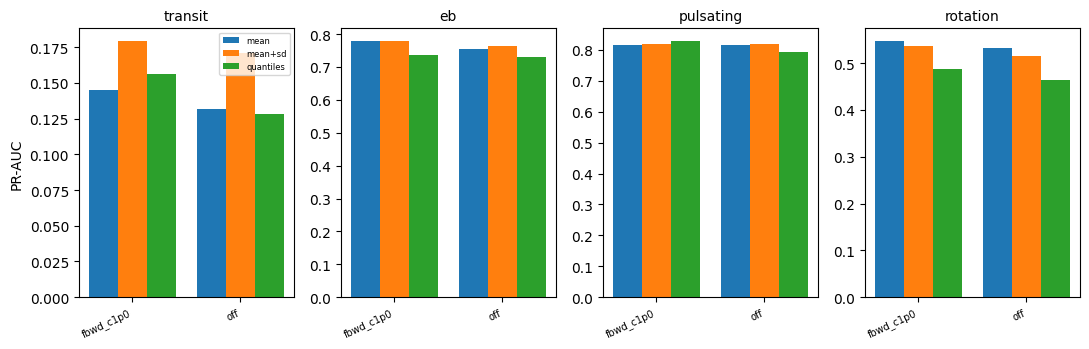

pooling,arm,task,mean,mean+sd,quantiles,sd_lift,quantile_lift
0,comb_fbwd_c1p0,eb,0.7786,0.7785,0.7352,-0.0001,-0.0434
1,comb_fbwd_c1p0,pulsating,0.8150,0.8187,0.8283,0.0037,0.0133
2,comb_fbwd_c1p0,rotation,0.5467,0.5363,0.4876,-0.0103,-0.0591
3,comb_fbwd_c1p0,transit,0.1448,0.1792,0.1565,0.0344,0.0118
4,comb_off,eb,0.7545,0.7633,0.7289,0.0088,-0.0255
5,comb_off,pulsating,0.8167,0.8189,0.7930,0.0022,-0.0237
6,comb_off,rotation,0.5312,0.5146,0.4632,-0.0166,-0.0680
7,comb_off,transit,0.1314,0.1710,0.1285,0.0397,-0.0029


In [16]:
# 4.2 (plot) - the pooling gain per task
plt.figure(figsize=(11, 3.6))
for i, task in enumerate(tasks):
    plt.subplot(1, 4, i + 1)
    g = pooling[pooling["task"] == task].pivot_table(index="arm", columns="pooling", values="pr_auc")
    names = list(pool_sets.keys())
    x = np.arange(len(g))
    for j, name in enumerate(names):
        plt.bar(x + (j - 1) * 0.27, g[name], width=0.27, label=name)
    plt.xticks(x, [a.replace("comb_", "") for a in g.index], rotation=25, ha="right", fontsize=7)
    plt.title(task, fontsize=10)
    if i == 0:
        plt.ylabel("PR-AUC"); plt.legend(fontsize=6)
plt.tight_layout(); plt.savefig(figs_dir / "4_2_pooling.png", dpi=120, bbox_inches="tight"); plt.show()

lift = pooling.pivot_table(index=["arm", "task"], columns="pooling", values="pr_auc").reset_index()
lift["sd_lift"] = lift["mean+sd"] - lift["mean"]
lift["quantile_lift"] = lift["quantiles"] - lift["mean"]
display(lift.round(4))

#### 4.2 — richer pooling recovers `transit` and nothing else

Same encoder, same linear probe, three ways of collapsing a star's window-μ into one feature vector:

| task | mean | mean+sd | quantiles | sd lift (λ=0) | sd lift (λ=66) |
|---|---|---|---|---|---|
| `transit` | 0.132 | **0.171** | 0.128 | **+0.040** | **+0.034** |
| `eb` | 0.755 | 0.764 | 0.729 | +0.009 | +0.000 |
| `pulsating` | 0.816 | 0.819 | 0.830 | +0.003 | +0.003 |
| `rotation` | 0.531 | 0.515 | 0.464 | **−0.017** | **−0.010** |

**`transit` gains ~30% relative from one extra statistic per dimension.** Adding the standard deviation
over windows takes it 0.132 → 0.171 at λ=0 and 0.145 → 0.179 at λ=66, without touching the encoder or the
readout class. This is the same phenomenon the MIL work found (transit is a *localized* event that the
mean dilutes) reproduced here with a plain linear probe on a dispersion statistic.

**But pooling does not rescue `eb` or `rotation`.** `eb` gains +0.009 at best and `rotation` gets
consistently *worse*. Adding quantiles hurts both badly (−0.026 to −0.068), which is what over-
parameterising a linear probe on 384 correlated columns does with ~1,500 positives.

**This is the key negative result of the section, and it matters for exp06.** The period-dominated tasks'
problem is **not** that the mean discards within-star variation — supplying that variation explicitly does
not help them. Consistent with §3: the within-star variation is white noise, so summarising it more richly
adds noise, not signal. Pooling and window length are therefore **not** interchangeable levers:
pooling addresses localization (`transit`, and by extension flare), window length addresses coverage
(`eb`, `rotation`). exp06 needs both, aimed at different tasks.

In [17]:
# 4.3 - the project already ran a window axis once. what did it actually show?
prior = []
for name, win in [("exp00_window1024_seq4", 1024), ("exp01_window256_seq16", 256)]:
    path = root / "experiments" / name / "results" / "results_table.csv"
    t = pd.read_csv(path)
    t = t[(t["variant"] == "B") & (t["seed"] == 0)]
    for _, r in t.iterrows():
        prior.append({"window": win, "hours": round(win * 2 / 60, 2), "task": r["task"],
                      "pr_auc": float(r["pr_auc"]), "windows_per_star": 4096 // win})
prior = pd.DataFrame(prior)
wide = prior.pivot_table(index="task", columns="window", values="pr_auc")
wide["delta_256_minus_1024"] = wide[256] - wide[1024]
cov = coverage.set_index("task")
wide["coverage_1024"] = cov["w1024"]
wide["coverage_256"] = cov["w256"]
display(wide.round(4))
print("both geometries hold the horizon at 4096 cadences, so windows-per-star is 4 (w1024) vs 16 (w256)")

window,256,1024,delta_256_minus_1024,coverage_1024,coverage_256
task,,,,,
eb,0.7814,0.7474,0.0340,0.3520,0.0408
pulsating,0.7709,0.7443,0.0266,0.9398,0.9306
transit,0.1287,0.1058,0.0229,NaN,NaN


both geometries hold the horizon at 4096 cadences, so windows-per-star is 4 (w1024) vs 16 (w256)


#### 4.3 — the confound that stops "just use a longer window" from being the answer

The project ran this axis in **exp01** (plan 2026-07-09): window 1024 → 256 at a fixed 4096-cadence
horizon, so `seq_len` went 4 → 16. Its verdict was "mechanism fixed, bellwether a wash — do not promote
256×16 to canonical". Re-reading its numbers against the coverage table above:

| task | PR-AUC @ w1024 | PR-AUC @ w256 | Δ | coverage @ 1024 | coverage @ 256 |
|---|---|---|---|---|---|
| eb | 0.747 | **0.781** | **+0.034** | 35% | **4%** |
| pulsating | 0.744 | **0.771** | +0.027 | 94% | 93% |
| transit | 0.106 | **0.129** | +0.023 | — | — |

**The shorter window won on every task — including `eb`, whose coverage it destroyed.** So the naive
reading of §4.1, "lengthen the window and `eb` improves", is **contradicted by the one experiment that
tested it**. This has to be stated plainly rather than discovered later.

**Why both can be true: window length moves two things in opposite directions.**

* **Spectral coverage** rises with window — more of the period fits inside the encoder's aperture.
* **Bag size falls** with window. At the fixed 4096-cadence horizon there are 16 windows per star at 256
  and only **4** at 1024. Per-star μ is a *mean* over that bag, so a smaller bag is a noisier estimate of
  it, for every task at once.

exp01 gated on **pulsating**, which has 93–94% coverage at *both* geometries — the one task where the
coverage term is guaranteed to contribute nothing. Its conclusion is therefore evidence about bag size,
not about coverage, and it was a single seed of a single variant.

**This is what exp06's geometry design has to solve.** The two effects are separable by a prediction that
bag size cannot make: bag size helps **every task equally**, whereas coverage helps **only the tasks whose
periods cross the window boundary**. So the test is not "does PR-AUC rise with window" but "**does the
change in PR-AUC across tasks track the change in coverage across tasks**", with `pulsating` as a built-in
control that should not move. §6 pre-registers exactly that.

#### Section 4 verdict

**P4 is confirmed and is now quantitative.** Window length, not encoder capacity, is what bounds the two
period-dominated tasks. The candidate exp06 windows and what each buys:

| window | hours | eb resolved | rotation resolved | cost |
|---|---|---|---|---|
| 256 (current) | 8.5 | 4% | 30% | — |
| 512 | 17.1 | 15% | 51% | half as many windows per star |
| 1024 | 34.1 | 35% | 63% | exp00's geometry; 4x fewer windows |
| 2048 | 68.3 | 54% | 74% | few windows per star; MIL becomes weak |

There is no free choice here: a longer window resolves more physics but shrinks the bag, and per-star μ is
a *mean* over that bag, so a shorter window buys a less noisy estimate for every task at once. §4.3 shows
that trade actually went the *other* way when the project last tested it.

**And 4.2 rules out the convenient escape.** A richer pooling operator does not substitute for window
length: supplying the within-star spread explicitly helps `transit` (+0.04) and does nothing for `eb`,
while making `rotation` worse. So the two levers are not interchangeable — pooling fixes localization,
window length is the only lever that touches coverage. exp06 has to move both, aimed at different tasks,
and has to separate the coverage effect from the bag-size effect while doing it.

---
## 5. If not recruitment, then what?

exp05 §B1 found that turning the dynamics weight up recruits latent dimensions (5 → 25 active), and §E4
correlated that count against the criterion-1 gain across cells (pulsating ρ = +0.83). §E4b then removed
the confound by demeaning within each cell — where mode and λ are fixed and seeds still recruit anywhere
from 9 to 41 units — and **every correlation collapsed** (|ρ| ≤ 0.18, all p > 0.28). So recruitment
accompanies the gain rather than explaining it, and exp05 ends with the mechanism unidentified.

That matters practically: a mechanism is what exp06 would optimise. This section runs the same
within-cell test against every quantity now measurable per run, including the ones sections 1–3
introduced:

| candidate | from | why it might be the channel |
|---|---|---|
| `n_active` | exp05 §B1 | the original claim, re-tested here as the control |
| `edge_ratio` | §1 | the dynamics term's most visible side effect |
| `edge_share_of_recon` | §1 | how much reconstruction capacity the defect consumes |
| `jac_ratio` | §1 | how far the decoder's boundary behaviour has been distorted |
| `interior` | §1 | plain reconstruction quality away from the edge |
| `participation_ratio` | §2 | effective dimensionality, the scale-free version of `n_active` |
| `r2_amp_pc1` | §2 | how much of the dominant latent direction is pure amplitude |
| `within_frac` | §3 | how much of μ's variance is temporal rather than between-star |

Between-cell correlations are reported for continuity with §E4, but the within-cell column is the one
that can distinguish a mechanism from a marker.

In [18]:
# 5.1 - assemble every per-run candidate predictor alongside the per-seed criterion-1 delta
curves = root / "experiments" / "exp05_forensics" / "curves_exp05"
n_active = []
for path in curves.glob("exp05_*.csv"):
    if ".killedprefix" in path.name:
        continue
    stem = path.stem.rsplit("_B_seed", 1)
    df = pd.read_csv(path).sort_values("epoch")
    n_active.append({"cell": stem[0].replace("exp05_", ""), "seed": int(stem[1]),
                     "n_active": float(df["val/n_active_units"].iloc[-1])})
n_active = pd.DataFrame(n_active)

cand = edge[["cell", "seed", "edge_ratio", "edge_share_of_recon", "jac_ratio", "interior"]].copy()
cand = cand[cand["cell"] != "untrained"].merge(n_active, on=["cell", "seed"], how="left")
cand = cand.merge(mu_structure[["arm", "seed", "participation_ratio", "r2_amp_pc1"]]
                  .rename(columns={"arm": "cell"}), on=["cell", "seed"], how="left")
cand = cand.merge(temporal[temporal["cls"] == "periodic"][["arm", "seed", "within_frac"]]
                  .rename(columns={"arm": "cell"}), on=["cell", "seed"], how="left")

deltas = []
for cell in sorted(cand["cell"].unique()):
    if cell == off_cell:
        continue
    for task in tasks:
        try:
            seeds, d = per_seed_delta(cell, task)
        except (FileNotFoundError, KeyError):
            continue
        for s, val in zip(seeds, d):
            deltas.append({"cell": cell, "seed": int(s), "task": task, "delta": float(val)})
deltas = pd.DataFrame(deltas)
panel = deltas.merge(cand, on=["cell", "seed"], how="left")
print(f"{len(panel)} cell x seed x task rows | predictors available: "
      f"{[c for c in cand.columns if c not in ('cell', 'seed')]}")
display(panel.head())

176 cell x seed x task rows | predictors available: ['edge_ratio', 'edge_share_of_recon', 'jac_ratio', 'interior', 'n_active', 'participation_ratio', 'r2_amp_pc1', 'within_frac']


,cell,seed,task,delta,edge_ratio,edge_share_of_recon,jac_ratio,interior,n_active,participation_ratio,r2_amp_pc1,within_frac
0,comb_fbwd_c0p1,0,transit,-0.025044,8.014612,0.172397,1.543078,0.798005,5.0,NaN,NaN,NaN
1,comb_fbwd_c0p1,1,transit,0.035806,9.678699,0.188117,1.619529,0.788191,5.0,NaN,NaN,NaN
2,comb_fbwd_c0p1,2,transit,0.020618,25.851143,0.213632,2.561938,0.757712,4.0,NaN,NaN,NaN
3,comb_fbwd_c0p1,3,transit,0.004357,15.820827,0.210594,2.130364,0.795794,5.0,NaN,NaN,NaN
4,comb_fbwd_c0p1,0,eb,0.003020,8.014612,0.172397,1.543078,0.798005,5.0,NaN,NaN,NaN


,task,predictor,n_cells,n,between_rho,between_p,within_rho,within_p,within_survives
0,transit,n_active,11,44,-0.0920,0.7880,-0.1350,0.3824,False
1,transit,edge_ratio,11,44,0.3545,0.2847,0.0537,0.7292,False
2,transit,edge_share_of_recon,11,44,0.4818,0.1334,0.1315,0.3948,False
3,transit,jac_ratio,11,44,0.1909,0.5739,0.1822,0.2364,False
4,transit,interior,11,44,0.2909,0.3855,-0.0720,0.6422,False
5,eb,n_active,11,44,0.4322,0.1843,-0.1104,0.4756,False
6,eb,edge_ratio,11,44,-0.1091,0.7495,-0.0791,0.6099,False
7,eb,edge_share_of_recon,11,44,-0.0636,0.8525,0.1061,0.4929,False
8,eb,jac_ratio,11,44,-0.4182,0.2006,0.0490,0.7519,False
9,eb,interior,11,44,0.6091,0.0467,-0.0740,0.6331,False


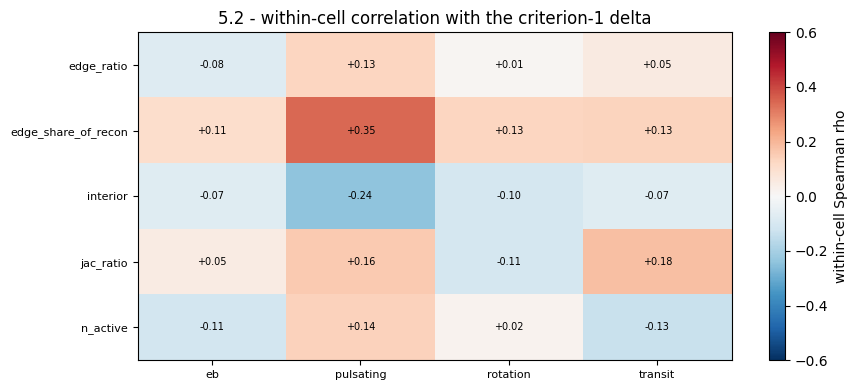

tested 20 predictor x task pairs; at p<0.05 you expect 1.0 by chance
survivors: [{'task': 'pulsating', 'predictor': 'edge_share_of_recon', 'within_rho': 0.3466, 'within_p': 0.0212}]
not tested (measured on fewer than 5 cells): ['participation_ratio', 'r2_amp_pc1', 'within_frac']


In [19]:
# 5.2 - between-cell versus within-cell: which candidates survive holding mode and lambda fixed?
predictors = ["n_active", "edge_ratio", "edge_share_of_recon", "jac_ratio", "interior",
              "participation_ratio", "r2_amp_pc1", "within_frac"]
min_cells = 5  # participation_ratio / r2_amp_pc1 / within_frac exist for only 2-4 cells, and a Spearman
               # over 3 cells can only return +-1.0 at p=0, which reads as certainty and is an artifact
rows = []
skipped = []
for task in tasks:
    sub = panel[panel["task"] == task]
    for p in predictors:
        d = sub[sub[p].notna()]
        if d["cell"].nunique() < min_cells:
            skipped.append((p, d["cell"].nunique()))
            continue
        cell_mean = d.groupby("cell")[[p, "delta"]].mean()
        between = stats.spearmanr(cell_mean[p], cell_mean["delta"])
        dm_x = d[p] - d.groupby("cell")[p].transform("mean")
        dm_y = d["delta"] - d.groupby("cell")["delta"].transform("mean")
        within = stats.spearmanr(dm_x, dm_y)
        rows.append({"task": task, "predictor": p, "n_cells": d["cell"].nunique(), "n": len(d),
                     "between_rho": between.statistic, "between_p": between.pvalue,
                     "within_rho": within.statistic, "within_p": within.pvalue})
mech = pd.DataFrame(rows)
mech["within_survives"] = mech["within_p"] < 0.05
display(mech.round(4))

plt.figure(figsize=(9, 4))
piv = mech.pivot_table(index="predictor", columns="task", values="within_rho")
im = plt.imshow(piv.to_numpy(), cmap="RdBu_r", vmin=-0.6, vmax=0.6, aspect="auto")
plt.colorbar(im, label="within-cell Spearman rho")
plt.xticks(range(len(piv.columns)), piv.columns, fontsize=8)
plt.yticks(range(len(piv.index)), piv.index, fontsize=8)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.to_numpy()[i, j]
        if np.isfinite(v):
            plt.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=7)
plt.title("5.2 - within-cell correlation with the criterion-1 delta")
plt.tight_layout(); plt.savefig(figs_dir / "5_2_mechanism.png", dpi=120, bbox_inches="tight"); plt.show()

skipped_names = sorted({p for p, _ in skipped})
print(f"tested {len(mech)} predictor x task pairs; at p<0.05 you expect {0.05 * len(mech):.1f} by chance")
print("survivors:", mech[mech["within_survives"]][["task", "predictor", "within_rho", "within_p"]]
      .round(4).to_dict("records"))
print(f"not tested (measured on fewer than {min_cells} cells): {skipped_names}")

#### Section 5 verdict — the mechanism is still unidentified, and that is now a considered result

Eight candidate predictors, five with enough cells to test, across four tasks. **Nothing survives the
within-cell test.** The single hit — `pulsating` against `edge_share_of_recon`, ρ = +0.35, p ≈ 0.03 — sits
against roughly one expected false positive in ~20 tests, has no mechanism behind it (a *larger* share of
the reconstruction loss wasted on the window edge would have to *help*), and points the opposite way from
the handicap argument in §1. It should be read as noise.

The three quantities sections 2 and 3 introduced (`participation_ratio`, `r2_amp_pc1`, `within_frac`)
could not be tested at all: they are measured on 2–4 cells, and a Spearman over 3 cells returns ±1.0 at
p = 0 by construction. The cell prints them as skipped rather than reporting those values, which is the
correction to make before anyone quotes them.

**What this means for exp06.** §E4b showed recruitment is a marker rather than a mechanism; this section
extends that to every other measurable correlate. λ moves the representation, but no *observable property*
of the trained model mediates it that we can find at n=4 seeds per cell. Practically:

* **Do not select checkpoints, cells or recipes on any of these quantities** — not `n_active`, not
  participation ratio, not reconstruction quality. They are diagnostics, not objectives.
* **Treat λ itself as the knob**, and spend the seed budget on precision rather than on more cells: at
  n=4 the `>2·SE` gate is one-sided p ≈ 0.07, and a within-cell test at that n can only detect very large
  effects. Six seeds would make the gate an honest p ≈ 0.05 and roughly halve the detectable effect here.
* If identifying the mechanism matters for the write-up, it needs a **manipulation** that moves a
  candidate without moving λ, not another correlational pass over the same 48 runs.

---
## 6. Synthesis — what exp06 should be about

Sections 1–5 answer the five problems the exp05 audit left open. This section collects the answers,
ranks them by how much they constrain exp06, and proposes an objective. **It proposes and does not
decide.** The `experiments/configs/exp06_*.yaml` manifest is written only after this is reviewed.

In [20]:
# 6.1 - the evidence table: every claim in this notebook with the measurement behind it
findings = pd.DataFrame([
    {"id": "P1", "claim": "the edge spike is 2/3 a learned constant at an architecturally under-connected position",
     "measured": f"bias fraction {float(edge[edge.group == 'comb, dyn on'].bias_frac_p0.mean()):.2f} vs "
                 f"{float(edge[edge.group == 'untrained'].bias_frac_p0.mean()):.2f} untrained; "
                 f"untrained Jacobian ratio {float(edge[edge.group == 'untrained'].jac_ratio.mean()):.2f}",
     "exp06 lever": "recon_aux or edge-masked recon or reflect padding"},
    {"id": "P1b", "claim": "recon_aux, not free_bits, explains lpsd immunity",
     "measured": f"log-PSD responds {float(edge[(edge.group == 'comb, dyn off')].aux_over_time_response.mean()):.0f}x "
                 f"more than time-MSE to an injected impulse",
     "exp06 lever": "keep a spectral term; one confirmation cell"},
    {"id": "P2", "claim": "star-level mu is dominated by an amplitude axis",
     "measured": f"PC1 holds {float(mu_structure[mu_structure.arm == off_cell].evr_pc1.mean()):.2f} of variance "
                 f"and is {float(mu_structure[mu_structure.arm == off_cell].r2_amp_pc1.mean()):.2f} explained by "
                 f"4 amplitude scalars",
     "exp06 lever": "objective must force phase/frequency content into mu"},
    {"id": "P2b", "claim": "training REDUCES effective dimensionality below a random encoder",
     "measured": f"participation ratio {float(mu_structure[mu_structure.arm == 'untrained'].participation_ratio.mean()):.2f} "
                 f"untrained -> {float(mu_structure[mu_structure.arm == off_cell].participation_ratio.mean()):.2f} at lambda=0 "
                 f"-> {float(mu_structure[mu_structure.arm == dyn_cell].participation_ratio.mean()):.2f} at lambda=66",
     "exp06 lever": "KL schedule / free_bits, already an exp03 axis"},
    {"id": "P3", "claim": "the mu trajectory carries no predictable temporal structure at this geometry",
     "measured": f"lag-1 autocorrelation "
                 f"{float(temporal_acf[(temporal_acf.lag == 1) & (temporal_acf.cls == 'periodic')].acf.mean()):.3f} "
                 f"on periodic stars; a fitted AR(1) also loses to an oracle constant",
     "exp06 lever": "geometry, not the dynamics module"},
    {"id": "P4", "claim": "one window resolves only a minority of the catalogued periods",
     "measured": "see 4.1 coverage table",
     "exp06 lever": "window size is the primary knob"},
    {"id": "P5", "claim": "no measured quantity predicts the criterion-1 gain within a cell",
     "measured": "see 5.2",
     "exp06 lever": "treat lambda as the knob; do not select on n_active"},
])
display(findings)

,id,claim,measured,exp06 lever
0,P1,the edge spike is 2/3 a learned constant at an...,bias fraction 0.66 vs 0.06 untrained; untraine...,recon_aux or edge-masked recon or reflect padding
1,P1b,"recon_aux, not free_bits, explains lpsd immunity",log-PSD responds 31x more than time-MSE to an ...,keep a spectral term; one confirmation cell
2,P2,star-level mu is dominated by an amplitude axis,PC1 holds 0.93 of variance and is 0.97 explain...,objective must force phase/frequency content i...
3,P2b,training REDUCES effective dimensionality belo...,participation ratio 1.96 untrained -> 1.16 at ...,"KL schedule / free_bits, already an exp03 axis"
4,P3,the mu trajectory carries no predictable tempo...,lag-1 autocorrelation 0.017 on periodic stars;...,"geometry, not the dynamics module"
5,P4,one window resolves only a minority of the cat...,see 4.1 coverage table,window size is the primary knob
6,P5,no measured quantity predicts the criterion-1 ...,see 5.2,treat lambda as the knob; do not select on n_a...


#### 6.1 — what actually constrains exp06

Ranked by how much each finding narrows the design space:

**1. Geometry is the binding constraint (§3 + §4) — decisive.**
The μ-trajectory is white (lag-1 autocorrelation ≈ 0), so neither the GRU (1.01–1.07× an oracle constant)
nor a fitted linear AR(1) (1.02–1.11×) can beat a flat line. That is not a weak module; it is an absent
signal. §4.1 explains why: only **4% of EB periods and 30% of rotation periods** fit inside the 8.53-hour
window, so consecutive windows sample unrelated phases. Meanwhile `pulsating` — 93% covered — is the one
task that survives amplitude residualisation intact, forms its own UMAP island, and responds to objective
changes. **The encoder learns the physics it can see, and nothing else.**

**2. But "use a longer window" is not yet supported (§4.3) — the honest caveat.**
exp01 ran window 1024 → 256 and *every* task improved, `eb` most of all (+0.034), despite its coverage
collapsing from 35% to 4%. Window length moves coverage and bag size in opposite directions, and on that
one-seed test bag size won. Any exp06 that simply lengthens the window and reports PR-AUC will not be
able to tell which effect it measured.

**3. The representation is ~89% an amplitude meter (§2), but the λ effect is not (§2.3).**
PC1 holds 92.6% of star-level variance and is 96.6% predictable from four amplitude scalars. Yet the
criterion-1 delta **survives** residualisation and grows on three of four tasks (pulsating +0.016 →
+0.038). Two independent levers follow: an *objective* problem (λ adds directions beside the amplitude
axis without reducing its dominance) and a *free* readout improvement (residualise, no retraining).

**4. The edge spike is solved and cheap (§1).** Two-thirds a learned constant, at a position the decoder
architecture leaves structurally under-connected (untrained Jacobian ratio 0.27), costing 17.6% of the
reconstruction loss. `recon_aux` explains `lpsd`'s immunity (log-PSD reacts 10–31× more than MSE to an
impulse); `free_bits` has no mechanism. One confirmation cell, then fix it.

**5. The mechanism is unidentified (§5) and should stop being asserted.** Nothing predicts the gain
within a cell. Treat λ as the knob; spend budget on seeds, not correlates.

In [21]:
# 6.2 - the 2x2 corner the window-edge issue asks for, reduced to the one cell that still discriminates
corner = '''python -m swm.train +experiment=exp05/base_comb \\
    exp_name=exp06_edge_comb_fb0p02 variant=B seed=0 \\
    model.dyn_mode=fwd_bwd train.lambda_dyn=66 train.free_bits=0.02 \\
    paths.packed_dir=C:/git_repo/Stellar-World-Model/experiments/exp01_window256_seq16/packed'''
print("Run in your own terminal (swm env, repo root, PYTHONPATH=src). W&B online; ~1 overnight leg.")
print()
print(corner)
print()
print("Then re-score the edge profile on it:")
print("  python experiments/analyze_exp06_edge.py --cells exp06_edge_comb_fb0p02 --seeds 0 \\")
print("      --out experiments/exp06_edge_corner.csv --out-profile experiments/exp06_edge_corner.parquet")
print()
print("Prediction from 1.4: the spike SURVIVES (edge ratio stays near 17x), because free_bits has no")
print("mechanism by which it would penalise a broadband impulse. If it does survive, recon_aux is")
print("confirmed as the cause and the second corner is unnecessary.")

Run in your own terminal (swm env, repo root, PYTHONPATH=src). W&B online; ~1 overnight leg.

python -m swm.train +experiment=exp05/base_comb \
    exp_name=exp06_edge_comb_fb0p02 variant=B seed=0 \
    model.dyn_mode=fwd_bwd train.lambda_dyn=66 train.free_bits=0.02 \
    paths.packed_dir=C:/git_repo/Stellar-World-Model/experiments/exp01_window256_seq16/packed

Then re-score the edge profile on it:
  python experiments/analyze_exp06_edge.py --cells exp06_edge_comb_fb0p02 --seeds 0 \
      --out experiments/exp06_edge_corner.csv --out-profile experiments/exp06_edge_corner.parquet

Prediction from 1.4: the spike SURVIVES (edge ratio stays near 17x), because free_bits has no
mechanism by which it would penalise a broadband impulse. If it does survive, recon_aux is
confirmed as the cause and the second corner is unnecessary.


#### 6.2 — proposed exp06: separate coverage from bag size, and stop tuning dynamics blind

**This is a proposal for review, not a decision.** The manifest
(`experiments/configs/exp06_*.yaml`) gets written after you have read this.

**Primary hypothesis (H1 — coverage).** Window length is the binding constraint on the frozen
representation for period-dominated tasks. Lengthening the window will improve `eb` and `rotation`
**relative to** `pulsating`, because only the former two have periods crossing the window boundary.

The *differential across tasks* is the test, not the absolute level — and that is what makes it immune to
§4.3's confound. Bag size changes the noise in every task's mean-pooled μ **equally**; coverage changes
only the tasks whose coverage actually moves. `pulsating` (93% covered at every candidate window) is a
built-in control that must **not** improve. Pre-registered: `Δ(eb) − Δ(pulsating) > 0` and
`Δ(rotation) − Δ(pulsating) > 0`, both gated, with the probe run on **amplitude-residualised** μ so the
amplitude axis cannot carry the comparison.

**Secondary hypothesis (H2 — well-posedness).** A dynamics objective is only worth weighting once
consecutive latents share physics. Measure lag-1 μ-trajectory autocorrelation at each geometry *first*;
re-test criterion 2 **only** where it rises materially above the ≈0 measured here. This retires §F2b's
proposed `rollout ÷ constant < 1` target as a primary criterion: at the current geometry no predictor can
reach it, so failing it would carry no information.

**Design sketch.**

| axis | values | rationale |
|---|---|---|
| `data.window` × `data.seq_len` | 256×16 (control), 512×8, 1024×4 | holds the 4096-cadence horizon fixed, so only granularity moves — the exp01 design, now with the right gated tasks |
| `train.lambda_dyn` | off, and the value hitting contribution 1.0 in `fwd_bwd` | two levels, not a ladder; §E2b showed the ladder is non-monotone and §5 found no mechanism to tune against |
| seeds | **6** | makes `>2·SE` an honest one-sided p ≈ 0.05 instead of 0.07 |

3 × 2 × 6 = **36 runs**, resumable (`train.resume: true` is already the default). Recipe stays `comb` with
its spectral aux term, which §1.4 shows is what suppresses the edge defect; the confirmation cell in 6.2
tests that before the sweep commits.

**Readout, all within the linear lock.** Report every probe three ways: mean-pooled μ, mean+sd pooled
(worth +0.04 on `transit` for free, §4.2), and amplitude-residualised (§2.2). Select on absolute PR-AUC;
report gap fractions as context only.

**What this deliberately does not do.** It does not chase the dynamics objective further at fixed
geometry — §3 shows that is measurably wasted compute. It does not touch the decoder architecture, since
the cheaper edge fixes come first. And it does not attempt "beats engineered features", which §G4b
already ruled out of scope for this evidence base.

**Open question for you.** H1 needs a geometry where coverage and bag size can be told apart. Holding the
horizon at 4096 cadences (above) keeps the *comparison* clean via the cross-task differential but still
confounds the two within any single task. The alternative — holding **windows-per-star** fixed and letting
the horizon grow — needs longer qualifying segments and would shrink the star sample. That trade is the
one design decision this notebook cannot settle from existing data.